# General dataframe statistics

In [27]:
import pandas as pd

kolom_analisis = ['starttime']
df_mini = pd.read_parquet('divvy_clean_v2.parquet', columns=kolom_analisis)

df_mini.head()

,starttime
0,2013-06-27 12:11:00
1,2013-06-27 14:44:00
2,2013-06-27 14:58:00
3,2013-06-27 15:06:00
4,2013-06-27 15:13:00


In [29]:
len(df_mini)

54887538

In [33]:
import pyarrow.parquet as pq

# Membaca metadata file saja (tidak memakan RAM)
file_parquet = pq.ParquetFile('divvy_clean_v2.parquet')

# Menampilkan semua daftar nama kolom yang ada di dalam file
print(file_parquet.schema.names)

['trip_id', 'starttime', 'stoptime', 'bikeid', 'tripduration', 'from_station_id', 'from_station_name', 'to_station_id', 'to_station_name', 'usertype', 'gender', 'birthyear', 'rideable_type', 'start_lat', 'start_lng', 'end_lat', 'end_lng']


# Column Check 

In [37]:
import pandas as pd

kolom_analisis = ['trip_id']
df = pd.read_parquet('divvy_total_2013_2026.parquet', columns=kolom_analisis)

df.head()

,trip_id
0,4118
1,4275
2,4291
3,4316
4,4342


In [47]:
# format era awal (2013)
print("--- Era Awal (Top 5) ---")
print(df.head(5))

# format era akhir (2026)
print("\n--- Era Akhir (Bottom 5) ---")
print(df.tail(5))

# sampel acak di tengah-tengah
print("\n--- Sampel Acak (Random 5) ---")
print(df.sample(5, random_state=42))

--- Era Awal (Top 5) ---
  trip_id
0    4118
1    4275
2    4291
3    4316
4    4342

--- Era Akhir (Bottom 5) ---
                   trip_id
54936112  ADDAA33CEBCAE733
54936113  82B10FA3994BC66A
54936114  AA0D5AAA0B59C8AA
54936115  3296360A7BC20FB8
54936116  064EC7698E4FF9B3

--- Sampel Acak (Random 5) ---
                   trip_id
49164062  104A5DD08F9090B2
5948599            8299288
846292             2775360
10834961          14376865
36288117  BED72AF8B7F21ACB


In [49]:
total_baris = len(df)
total_unik = df['trip_id'].nunique()
print(f"Total Baris: {total_baris} | Total Unik: {total_unik}")

Total Baris: 54936117 | Total Unik: 54935601


In [51]:
df["trip_id"].isnull().sum()

0

In [57]:
total_baris - total_unik

516

In [55]:
df_id = pd.read_parquet('divvy_total_2013_2026.parquet', columns=['trip_id', 'tripduration', 'from_station_name'])
kondisi_duplikat = df_id['trip_id'].duplicated(keep=False)
df_duplikat_all = df_id[kondisi_duplikat]
df_duplikat_sorted = df_duplikat_all.sort_values(by='trip_id')
print(f"Total baris berstatus duplikat (termasuk pasangannya): {len(df_duplikat_sorted)}")
df_duplikat_sorted.head(20)

Total baris berstatus duplikat (termasuk pasangannya): 1032


,trip_id,tripduration,from_station_name
42694264,011C8EF97AB0F30D,89995.0,Clifton Ave & Armitage Ave
43497528,011C8EF97AB0F30D,89996.0,Clifton Ave & Armitage Ave
43313861,01406457A85B0AFF,408.0,None
42526083,01406457A85B0AFF,408.0,None
24246493,021A73F8C18B932D,-1711676.0,Clark St & Winnemac Ave
24069568,021A73F8C18B932D,743.0,Clark St & Winnemac Ave
43493248,02606FBC7F8537EE,89992.0,Pine Grove Ave & Waveland Ave
42694596,02606FBC7F8537EE,89992.0,Pine Grove Ave & Waveland Ave
24037507,0334987B57662109,420.0,Broadway & Berwyn Ave
24260369,0334987B57662109,-1712069.0,Broadway & Berwyn Ave


In [59]:
df_dur = pd.read_parquet('divvy_total_2013_2026.parquet', columns=['tripduration'])

total_minus = (df_dur['tripduration'] <= 0).sum()
total_rows = len(df_dur)
persentase_minus = (total_minus / total_rows) * 100

print(f"Total baris dengan durasi minus/nol : {total_minus:,} baris")
print(f"Persentase dari keseluruhan data     : {persentase_minus:.4f}%")

Total baris dengan durasi minus/nol : 14,990 baris
Persentase dari keseluruhan data     : 0.0273%


In [82]:
# kita bersihkan or drop 14,990 baris. dilakukan terpisah di file lain, kita menggunakan chuncking 5jt data per cycle.
# filter dengan df= df[df["tripduration"] > 0] 
# kita ulang lagi melihat apakah ada duplikat.

In [84]:
kolom_analisis = ['trip_id', 'tripduration', 'from_station_name']
df = pd.read_parquet('divvy_total_2013_2026_clean.parquet', columns=kolom_analisis)

In [85]:
len(df)

54921127

In [86]:
total_baris = len(df)
total_unik = df['trip_id'].nunique()
print(f"Total Baris: {total_baris} | Total Unik: {total_unik}")

Total Baris: 54921127 | Total Unik: 54920820


In [87]:
total_baris - total_unik

307

In [88]:
kondisi_duplikat = df['trip_id'].duplicated(keep=False)
df_duplikat_all = df[kondisi_duplikat]
df_duplikat_sorted = df_duplikat_all.sort_values(by='trip_id')
print(f"Total baris berstatus duplikat (termasuk pasangannya): {len(df_duplikat_sorted)}")
df_duplikat_sorted.head(20)

Total baris berstatus duplikat (termasuk pasangannya): 614


,trip_id,tripduration,from_station_name
43483457,011C8EF97AB0F30D,89996.0,Clifton Ave & Armitage Ave
42680385,011C8EF97AB0F30D,89995.0,Clifton Ave & Armitage Ave
42512271,01406457A85B0AFF,408.0,None
43299810,01406457A85B0AFF,408.0,None
42680717,02606FBC7F8537EE,89992.0,Pine Grove Ave & Waveland Ave
43479178,02606FBC7F8537EE,89992.0,Pine Grove Ave & Waveland Ave
43712480,0354FD0756337B59,2393.0,None
42668144,0354FD0756337B59,2393.0,None
54377465,03C5375398BE0649,1092.0,None
53636661,03C5375398BE0649,1092.0,None


In [ ]:
#chuncking jg dimana keep first dan buang sisanya. droping duplikat.

In [96]:
kolom_analisis = ['trip_id', 'tripduration', 'from_station_name']
df = pd.read_parquet('divvy_total_2013_2026_final.parquet', columns=kolom_analisis)

In [97]:
total_baris = len(df)
total_unik = df['trip_id'].nunique()
print(f"Total Baris: {total_baris} | Total Unik: {total_unik}")

Total Baris: 54920820 | Total Unik: 54920820


In [98]:
total_baris - total_unik

0

In [ ]:
df['trip_id']

In [11]:
import pandas as pd
df_transisi = pd.read_parquet('divvy_total_2013_2026_final.parquet', columns=['trip_id', 'starttime'])
era_lama = df_transisi[df_transisi['trip_id'].str.len() < 12]
transaksi_terakhir_lama = era_lama.sort_values(by='starttime').tail(1)
era_baru = df_transisi[df_transisi['trip_id'].str.len() == 16]
transaksi_pertama_baru = era_baru.sort_values(by='starttime').head(1)

print("--- TRANSAKSI TERAKHIR SISTEM LAMA ---")
print(transaksi_terakhir_lama)

print("\n--- TRANSAKSI PERTAMA SISTEM BARU ---")
print(transaksi_pertama_baru)

--- TRANSAKSI TERAKHIR SISTEM LAMA ---
           trip_id           starttime
21239923  25962904 2019-12-31 23:57:17

--- TRANSAKSI PERTAMA SISTEM BARU ---
                   trip_id           starttime
54593422  1068AB1B8F12FE23 2020-01-01 00:04:44


# Starttime

In [22]:
df = pd.read_parquet("divvy_total_2013_2026_final.parquet", columns =['starttime'])
df.head()

,starttime
0,2013-06-27 12:11:00
1,2013-06-27 14:44:00
2,2013-06-27 14:58:00
3,2013-06-27 15:06:00
4,2013-06-27 15:13:00


In [16]:
df.max()

starttime   2026-05-31 23:57:08.778
dtype: datetime64[ns]

In [18]:
df.min()

starttime   2013-06-27 01:06:00
dtype: datetime64[ns]

In [70]:
dfc = df.copy()

In [72]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54920820 entries, 0 to 54920819
Data columns (total 1 columns):
 #   Column     Dtype         
---  ------     -----         
 0   starttime  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 419.0 MB


In [74]:
#hari apa yang tidak ada in a whole dataset?
tanggal_awal = dfc["starttime"].min().date()
tanggal_akhir = dfc["starttime"].max().date()


In [76]:
kalender_utuh = pd.date_range(start=tanggal_awal, end=tanggal_akhir).date
tanggal_ada = set(dfc["starttime"].dt.date)
hari_tidak_ada = [tgl for tgl in kalender_utuh if tgl not in tanggal_ada]
df_missing = pd.DataFrame(hari_tidak_ada, columns=["tanggal_kosong"])
df_missing.head()

,tanggal_kosong
0,2014-01-07
1,2014-01-08
2,2020-06-01
3,2020-06-02


In [79]:
df_missing['tanggal_kosong'] = pd.to_datetime(df_missing['tanggal_kosong'])
df_missing["nama_hari"] = df_missing["tanggal_kosong"].dt.day_name()
df_missing["tahun"] = df_missing["tanggal_kosong"].dt.year
df_missing

,tanggal_kosong,nama_hari,tahun
0,2014-01-07,Tuesday,2014
1,2014-01-08,Wednesday,2014
2,2020-06-01,Monday,2020
3,2020-06-02,Tuesday,2020


In [81]:
# apa tanggal spesifik yang paling banyak dan paling sedikit peminjamnya?
hitung_per_tanggal = dfc['starttime'].dt.date.value_counts()
print("Tanggal paling BANYAK peminjaman:", hitung_per_tanggal.idxmax(), f"({hitung_per_tanggal.max()} transaksi)")
print("Tanggal paling SEDIKIT peminjaman:", hitung_per_tanggal.idxmin(), f"({hitung_per_tanggal.min()} transaksi)")

Tanggal paling BANYAK peminjaman: 2021-08-14 (37324 transaksi)
Tanggal paling SEDIKIT peminjaman: 2014-01-06 (1 transaksi)


In [83]:
df_tren_tanggal = dfc['starttime'].dt.date.value_counts().reset_index()
df_tren_tanggal.columns = ['tanggal_spesifik', 'total_peminjaman']
df_tren_tanggal['tanggal_spesifik'] = pd.to_datetime(df_tren_tanggal['tanggal_spesifik'])
df_tren_tanggal['nama_hari'] = df_tren_tanggal['tanggal_spesifik'].dt.day_name()
print("--- 10 TANGGAL PALING RAMAI ---")
print(df_tren_tanggal.head(10))
print("\n--- 10 TANGGAL PALING SEPI ---")
print(df_tren_tanggal.tail(10))

--- 10 TANGGAL PALING RAMAI ---
  tanggal_spesifik  total_peminjaman nama_hari
0       2021-08-14             37324  Saturday
1       2021-07-17             37259  Saturday
2       2021-06-05             36695  Saturday
3       2021-06-19             36327  Saturday
4       2022-07-09             36145  Saturday
5       2021-07-31             35736  Saturday
6       2021-08-07             35574  Saturday
7       2023-06-10             35115  Saturday
8       2021-05-22             35017  Saturday
9       2022-04-23             34959  Saturday

--- 10 TANGGAL PALING SEPI ---
     tanggal_spesifik  total_peminjaman  nama_hari
4708       2020-05-31               193     Sunday
4709       2019-01-30               163  Wednesday
4710       2015-02-01               141     Sunday
4711       2013-12-25               125  Wednesday
4712       2014-01-01               123  Wednesday
4713       2014-01-02               112   Thursday
4714       2013-06-27                95   Thursday
4715       

In [144]:
# hari in a week timeframe - most user use bike and least user use bike
dfc['starttime'] = pd.to_datetime(dfc['starttime'])
dfc['nama_hari'] = dfc['starttime'].dt.day_name()

dfc_hari = dfc.groupby('nama_hari').size().reset_index(name="total_peminjaman")
dfc_hari = dfc_hari.sort_values(by="nama_hari", ascending=False).reset_index(drop=True)
print(dfc_hari)

   nama_hari  total_peminjaman
0  Wednesday           7868892
1    Tuesday           7805935
2   Thursday           7962337
3     Sunday           7323065
4   Saturday           8411728
5     Monday           7489772
6     Friday           8059091


In [107]:
print(f"Hari paling BANYAK peminjaman: {dfc_hari.iloc[0]['nama_hari']} ({dfc_hari.iloc[0]['total_peminjaman']:,} transaksi)")
print(f"Hari paling SEDIKIT peminjaman: {dfc_hari.iloc[-1]['nama_hari']} ({dfc_hari.iloc[-1]['total_peminjaman']:,} transaksi)")

Hari paling BANYAK peminjaman: Saturday (8,411,728 transaksi)
Hari paling SEDIKIT peminjaman: Sunday (7,323,065 transaksi)


In [126]:
#apa bulan yang paling banyak data paling sedikit peminjamnya?
dfc["nama_bulan"] = dfc["starttime"].dt.month_name()
dfc_bulan = dfc.groupby("nama_bulan").size().reset_index(name="total_peminjam")
urutan_kalender = [
    'January', 'February', 'March', 'April', 'May', 'June', 
    'July', 'August', 'September', 'October', 'November', 'December'
]
dfc_bulan = dfc_bulan.set_index('nama_bulan').reindex(urutan_kalender).reset_index()

# Tampilkan hasil
dfc_bulan

,nama_bulan,total_peminjam
0,January,1457969
1,February,1618460
2,March,2687614
3,April,3754310
4,May,5794837
5,June,6632458
6,July,7678870
7,August,7747232
8,September,6981835
9,October,5524991


C:\Users\Bocah\AppData\Local\Temp\ipykernel_2748\142710970.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


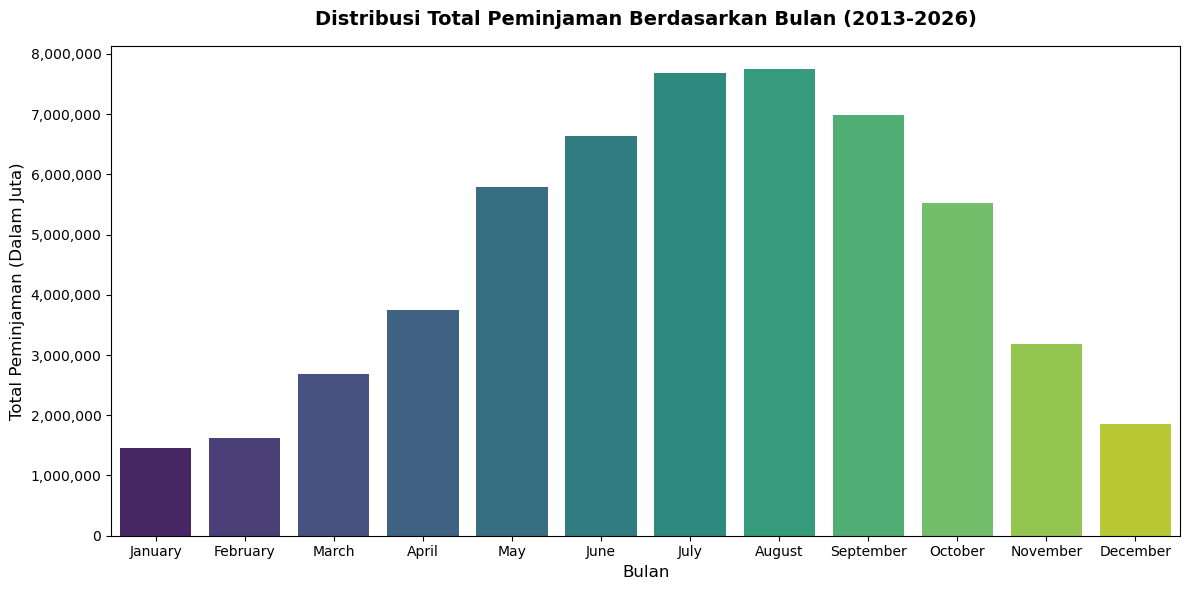

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set ukuran kanvas grafik
plt.figure(figsize=(12, 6))

# Membuat bar chart horizontal agar nama bulan mudah dibaca
sns.barplot(
    y='total_peminjam', 
    x='nama_bulan', 
    data=dfc_bulan, 
    palette='viridis' # Memberikan gradasi warna otomatis yang estetik
)

# Menambahkan judul dan label kapabilitas bisnis
plt.title('Distribusi Total Peminjaman Berdasarkan Bulan (2013-2026)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Total Peminjaman (Dalam Juta)', fontsize=12)
plt.xlabel('Bulan', fontsize=12)

# Mengatur agar angka di sumbu X menggunakan pemisah ribuan agar rapi
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Tampilkan grafik
plt.tight_layout()
plt.show()

In [148]:
#apa tahun yang paling banyak data paling sedikit peminjamnya?
dfc["nama_tahun"] = dfc["starttime"].dt.year
dfc_tahun = dfc.groupby("nama_tahun").size().reset_index(name="total_peminjam")

dfc_tahun = dfc_tahun.sort_values(by="nama_tahun", ascending=True).reset_index(drop=True)

# Tampilkan hasil
dfc_tahun

,nama_tahun,total_peminjam
0,2013,759788
1,2014,2454634
2,2015,3183439
3,2016,3595333
4,2017,3829003
5,2018,3601571
6,2019,3816156
7,2020,3530557
8,2021,5594410
9,2022,5667186


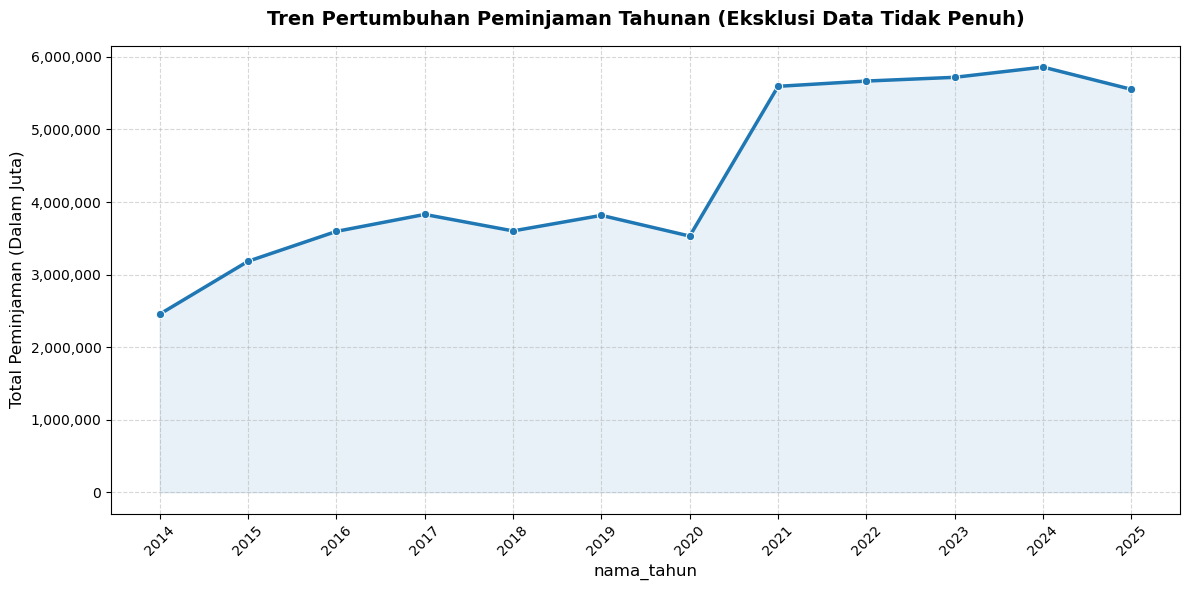

In [154]:
import matplotlib.pyplot as plt
import seaborn as sns
df_tahun = dfc.groupby('nama_tahun').size().reset_index(name='total_peminjam')
df_tahun = df_tahun.sort_values(by='nama_tahun').reset_index(drop=True)
df_tren_bersih = df_tahun.drop(index=[0, 13], errors='ignore').reset_index(drop=True)

# ---- PEMBUATAN TREND CHART ----
plt.figure(figsize=(12, 6))
sns.lineplot(
    x='nama_tahun', 
    y='total_peminjam', 
    data=df_tren_bersih, 
    marker='o',          
    linewidth=2.5,      
    color='#1f77b4'    
)

plt.fill_between(df_tren_bersih['nama_tahun'], df_tren_bersih['total_peminjam'], alpha=0.1, color='#1f77b4')

plt.title('Tren Pertumbuhan Peminjaman Tahunan (Eksklusi Data Tidak Penuh)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('nama_tahun', fontsize=12)
plt.ylabel('Total Peminjaman (Dalam Juta)', fontsize=12)
plt.xticks(df_tren_bersih['nama_tahun'], rotation=45)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [158]:
dfc.nama_hari.unique()

array(['Thursday', 'Friday', 'Saturday', 'Sunday', 'Monday', 'Tuesday',
       'Wednesday'], dtype=object)

In [168]:
#apa distribusi harian senin - minggu
dfc["nama_hari"] = dfc["starttime"].dt.day_name()
dfc_harian = dfc.groupby("nama_hari").size().reset_index(name="total_peminjam")
urutan_kalender = [
    'Monday', 'Tuesday','Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
]
dfc_harian = dfc_harian.set_index('nama_hari').reindex(urutan_kalender).reset_index()

# Tampilkan hasil
dfc_harian

,nama_hari,total_peminjam
0,Monday,7489772
1,Tuesday,7805935
2,Wednesday,7868892
3,Thursday,7962337
4,Friday,8059091
5,Saturday,8411728
6,Sunday,7323065


C:\Users\Bocah\AppData\Local\Temp\ipykernel_2748\3078746792.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


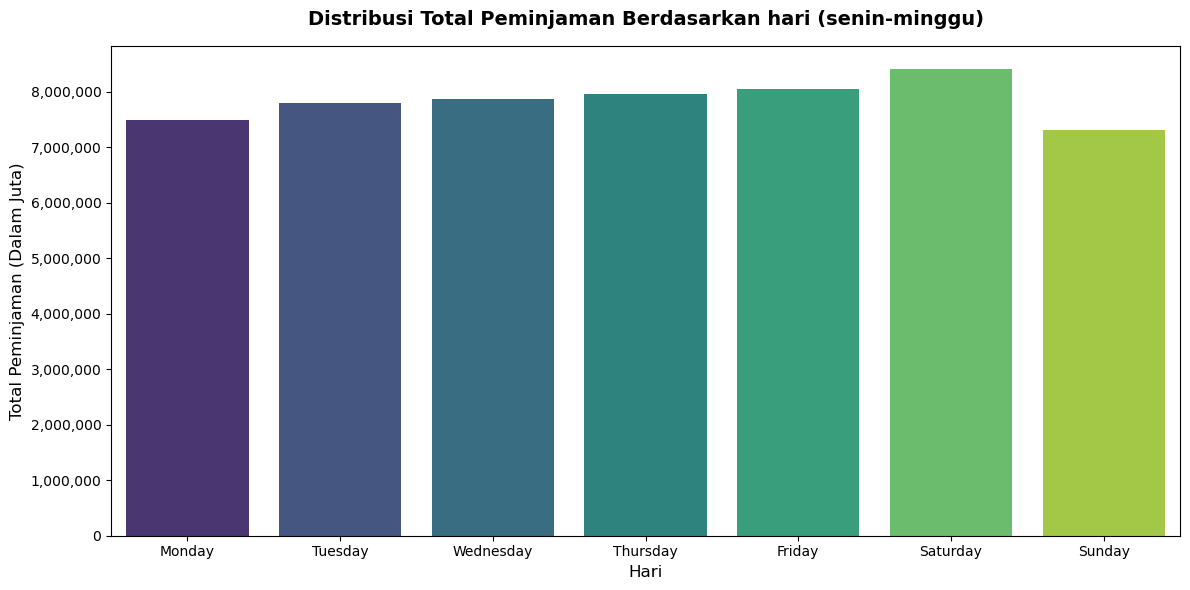

In [170]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set ukuran kanvas grafik
plt.figure(figsize=(12, 6))

# Membuat bar chart horizontal agar nama bulan mudah dibaca
sns.barplot(
    y='total_peminjam', 
    x='nama_hari', 
    data=dfc_harian, 
    palette='viridis' # Memberikan gradasi warna otomatis yang estetik
)

# Menambahkan judul dan label kapabilitas bisnis
plt.title('Distribusi Total Peminjaman Berdasarkan hari (senin-minggu)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Total Peminjaman (Dalam Juta)', fontsize=12)
plt.xlabel('Hari', fontsize=12)

# Mengatur agar angka di sumbu X menggunakan pemisah ribuan agar rapi
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Tampilkan grafik
plt.tight_layout()
plt.show()

In [172]:
# distribusi dalam 24 jam, paling
dfc["nama_jam"] = dfc["starttime"].dt.hour
dfc

,starttime,nama_hari,nama_bulan,nama_tahun,nama_jam
0,2013-06-27 12:11:00,Thursday,June,2013,12
1,2013-06-27 14:44:00,Thursday,June,2013,14
2,2013-06-27 14:58:00,Thursday,June,2013,14
3,2013-06-27 15:06:00,Thursday,June,2013,15
4,2013-06-27 15:13:00,Thursday,June,2013,15
...,...,...,...,...,...
54920815,2020-03-10 10:40:06,Tuesday,March,2020,10
54920816,2020-03-07 15:25:55,Saturday,March,2020,15
54920817,2020-03-01 13:12:38,Sunday,March,2020,13
54920818,2020-03-07 18:02:45,Saturday,March,2020,18


In [184]:
dfc_jam = dfc.groupby("nama_jam").size().reset_index(name="total_peminjam")
urutan_jam = [
    0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 
    10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 
    20, 21, 22, 23
]
dfc_jam = dfc_jam.set_index('nama_jam').reindex(urutan_jam).reset_index()

# Tampilkan hasil
dfc_jam

,nama_jam,total_peminjam
0,0,584230
1,1,369921
2,2,224367
3,3,133426
4,4,131271
5,5,430137
6,6,1298663
7,7,2628041
8,8,3368486
9,9,2269233


In [196]:
index_tertinggi = dfc_jam['total_peminjam'].idxmax()
dfc_jam.loc[[index_tertinggi]]

,nama_jam,total_peminjam
17,17,5968302


In [198]:
index_terendah = dfc_jam['total_peminjam'].idxmin()
dfc_jam.loc[[index_terendah]]

,nama_jam,total_peminjam
4,4,131271


C:\Users\Bocah\AppData\Local\Temp\ipykernel_2748\1060626368.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


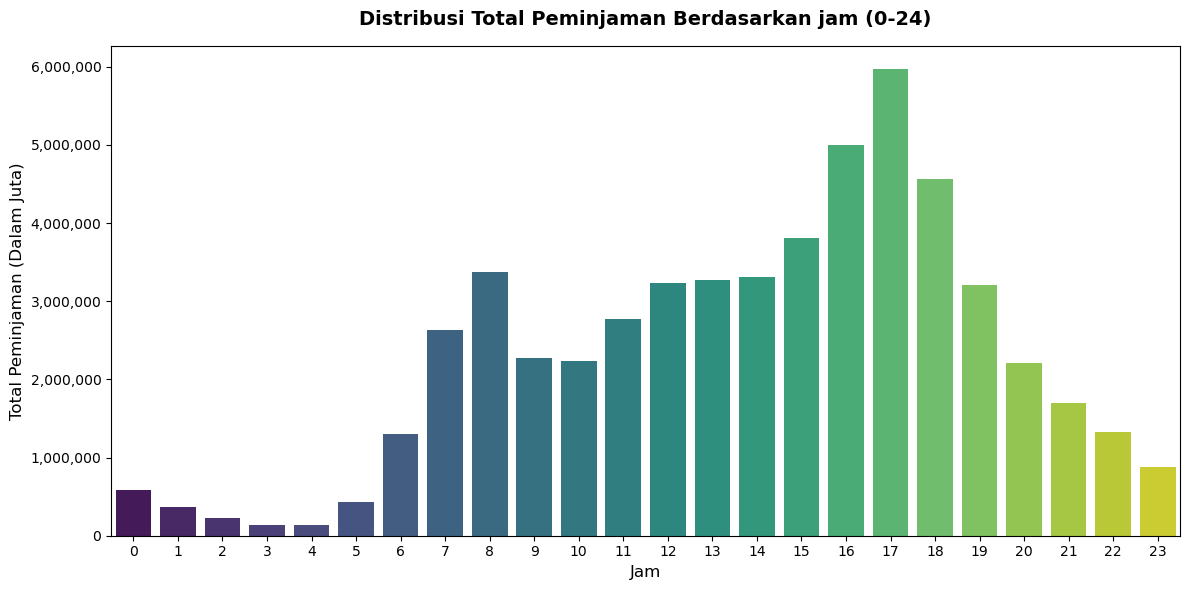

In [200]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set ukuran kanvas grafik
plt.figure(figsize=(12, 6))

# Membuat bar chart horizontal agar nama bulan mudah dibaca
sns.barplot(
    y='total_peminjam', 
    x='nama_jam', 
    data=dfc_jam, 
    palette='viridis' # Memberikan gradasi warna otomatis yang estetik
)

# Menambahkan judul dan label kapabilitas bisnis
plt.title('Distribusi Total Peminjaman Berdasarkan jam (0-24)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Total Peminjaman (Dalam Juta)', fontsize=12)
plt.xlabel('Jam', fontsize=12)

# Mengatur agar angka di sumbu X menggunakan pemisah ribuan agar rapi
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Tampilkan grafik
plt.tight_layout()
plt.show()

In [202]:
dfc

,starttime,nama_hari,nama_bulan,nama_tahun,nama_jam
0,2013-06-27 12:11:00,Thursday,June,2013,12
1,2013-06-27 14:44:00,Thursday,June,2013,14
2,2013-06-27 14:58:00,Thursday,June,2013,14
3,2013-06-27 15:06:00,Thursday,June,2013,15
4,2013-06-27 15:13:00,Thursday,June,2013,15
...,...,...,...,...,...
54920815,2020-03-10 10:40:06,Tuesday,March,2020,10
54920816,2020-03-07 15:25:55,Saturday,March,2020,15
54920817,2020-03-01 13:12:38,Sunday,March,2020,13
54920818,2020-03-07 18:02:45,Saturday,March,2020,18


In [204]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54920820 entries, 0 to 54920819
Data columns (total 1 columns):
 #   Column     Dtype         
---  ------     -----         
 0   starttime  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 419.0 MB


# BIKEID

In [208]:
kolom_analisis = ['bikeid']
df = pd.read_parquet('divvy_total_2013_2026_final.parquet', columns=kolom_analisis)

df.head()

,bikeid
0,480.0
1,77.0
2,77.0
3,77.0
4,77.0


In [210]:
df.tail()

,bikeid
54920815,NaN
54920816,NaN
54920817,NaN
54920818,NaN
54920819,NaN


In [216]:
df.max()

bikeid    6946.0
dtype: float64

In [222]:
len(df["bikeid"].unique())

6526

# tripduration

In [226]:
kolom_analisis = ['tripduration']
df = pd.read_parquet('divvy_total_2013_2026_final.parquet', columns=kolom_analisis)

df.head()

,tripduration
0,316.0
1,64.0
2,433.0
3,123.0
4,852.0


In [228]:
316 / 60

5.266666666666667

In [230]:
dfc = df.copy()

In [232]:
dfc["tripduration_menit"] = dfc["tripduration"] / 60
dfc.head()

,tripduration,tripduration_menit
0,316.0,5.266667
1,64.0,1.066667
2,433.0,7.216667
3,123.0,2.050000
4,852.0,14.200000


In [238]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
dfc.describe()

,tripduration,tripduration_menit
count,54920820.00,54920820.00
mean,1116.82,18.61
std,8028.42,133.81
min,1.00,0.02
25%,373.00,6.22
50%,654.00,10.90
75%,1161.00,19.35
max,9387024.00,156450.40


In [242]:
dfc.isnull().sum()

tripduration          0
tripduration_menit    0
dtype: int64

In [244]:
dfc["tripduration"].max()

9387024.0

In [246]:
top_10_detik = dfc["tripduration"].nlargest(10)
print("--- TOP 10 DURASI TERLAMA (DETIK) ---")
print(top_10_detik)

--- TOP 10 DURASI TERLAMA (DETIK) ---
54550538   9387024.00
54755429   8636205.00
54654335   7039405.00
39510466   5909344.00
54854557   5627611.00
38793667   5554195.00
54599381   5399506.00
54722635   5386959.00
38893020   5002955.00
39434756   4786501.00
Name: tripduration, dtype: float64


In [248]:
jumlah_bocor = (dfc['tripduration'] > 86400).sum()
total_rows = len(dfc)
persentase = (jumlah_bocor / total_rows) * 100

print(f"Jumlah data yang melebihi 24 jam : {jumlah_bocor:,} baris")
print(f"Persentase data bocor           : {persentase:.4f}% dari total data")

Jumlah data yang melebihi 24 jam : 33,282 baris
Persentase data bocor           : 0.0606% dari total data


In [1]:
import pyarrow.parquet as pq
import pyarrow as pa
import pandas as pd

file_input = 'divvy_total_2013_2026_final.parquet'
file_output = 'divvy_total_2013_2026_final_clean.parquet'

parquet_file = pq.ParquetFile(file_input)
num_row_groups = parquet_file.num_row_groups

print(f"Total terdapat {num_row_groups} row groups yang akan diproses.")

writer = None
total_input_rows = 0
total_output_rows = 0

for i in range(num_row_groups):
    df_chunk = parquet_file.read_row_group(i).to_pandas()
    total_input_rows += len(df_chunk)
    df_chunk_clean = df_chunk[df_chunk['tripduration'] <= 86400]
    total_output_rows += len(df_chunk_clean)
    table_chunk = pa.Table.from_pandas(df_chunk_clean, preserve_index=False)
    
    if writer is None:
        writer = pq.ParquetWriter(file_output, table_chunk.schema, compression='snappy')
    
    writer.write_table(table_chunk)
    print(f"Memproses Group {i+1}/{num_row_groups}... Berhasil menyaring {len(df_chunk) - len(df_chunk_clean):,} baris bocor.", end='\r')

if writer:
    writer.close()

print("\n\n--- PROSES PEMBERSIHAN SELESAI ---")
print(f"Total baris sebelum dibersihkan : {total_input_rows:,}")
print(f"Total baris setelah dibersihkan : {total_output_rows:,}")
print(f"Total baris berhasil dibuang    : {total_input_rows - total_output_rows:,}")
print(f"File bersih disimpan ke         : {file_output}")

Total terdapat 55 row groups yang akan diproses.
Memproses Group 55/55... Berhasil menyaring 461 baris bocor.r.

--- PROSES PEMBERSIHAN SELESAI ---
Total baris sebelum dibersihkan : 54,920,820
Total baris setelah dibersihkan : 54,887,538
Total baris berhasil dibuang    : 33,282
File bersih disimpan ke         : divvy_total_2013_2026_final_clean.parquet


In [3]:
kolom_analisis = ['tripduration']
df = pd.read_parquet('divvy_total_2013_2026_final_clean.parquet', columns=kolom_analisis)

df.head()

,tripduration
0,316.0
1,64.0
2,433.0
3,123.0
4,852.0


In [5]:
df.max()

tripduration    86400.0
dtype: float64

In [7]:
df.min()

tripduration    1.0
dtype: float64

In [9]:
kolom_analisis = ['starttime']
df = pd.read_parquet('divvy_total_2013_2026_final_clean.parquet', columns=kolom_analisis)

df.head()

,starttime
0,2013-06-27 12:11:00
1,2013-06-27 14:44:00
2,2013-06-27 14:58:00
3,2013-06-27 15:06:00
4,2013-06-27 15:13:00


In [11]:
dfc = df.copy()
df_tren_tanggal = dfc['starttime'].dt.date.value_counts().reset_index()
df_tren_tanggal.columns = ['tanggal_spesifik', 'total_peminjaman']
df_tren_tanggal['tanggal_spesifik'] = pd.to_datetime(df_tren_tanggal['tanggal_spesifik'])
df_tren_tanggal['nama_hari'] = df_tren_tanggal['tanggal_spesifik'].dt.day_name()
print("--- 10 TANGGAL PALING RAMAI ---")
print(df_tren_tanggal.head(10))
print("\n--- 10 TANGGAL PALING SEPI ---")
print(df_tren_tanggal.tail(10))

--- 10 TANGGAL PALING RAMAI ---
  tanggal_spesifik  total_peminjaman nama_hari
0       2021-08-14             37291  Saturday
1       2021-07-17             37232  Saturday
2       2021-06-05             36648  Saturday
3       2021-06-19             36291  Saturday
4       2022-07-09             36105  Saturday
5       2021-07-31             35705  Saturday
6       2021-08-07             35550  Saturday
7       2023-06-10             35064  Saturday
8       2021-05-22             34980  Saturday
9       2022-04-23             34894  Saturday

--- 10 TANGGAL PALING SEPI ---
     tanggal_spesifik  total_peminjaman  nama_hari
4708       2020-05-31               193     Sunday
4709       2019-01-30               163  Wednesday
4710       2015-02-01               141     Sunday
4711       2013-12-25               125  Wednesday
4712       2014-01-01               123  Wednesday
4713       2014-01-02               112   Thursday
4714       2013-06-27                95   Thursday
4715       

In [1]:
# tidak ada perubahan signifikan jadi oke saja.

In [5]:
import pandas as pd
kolom_analisis = ['tripduration']
df = pd.read_parquet('divvy_total_2013_2026_final_clean.parquet', columns=kolom_analisis)

df.head()

,tripduration
0,316.0
1,64.0
2,433.0
3,123.0
4,852.0


In [7]:
dfc = df.copy()

In [11]:
dfc["tripduration_menit"] = dfc["tripduration"] / 60
dfc.head()

,tripduration,tripduration_menit
0,316.0,5.266667
1,64.0,1.066667
2,433.0,7.216667
3,123.0,2.050000
4,852.0,14.200000


In [13]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
dfc.describe()

,tripduration,tripduration_menit
count,54887538.00,54887538.00
mean,1022.39,17.04
std,1971.22,32.85
min,1.00,0.02
25%,373.00,6.22
50%,654.00,10.90
75%,1160.00,19.33
max,86400.00,1440.00


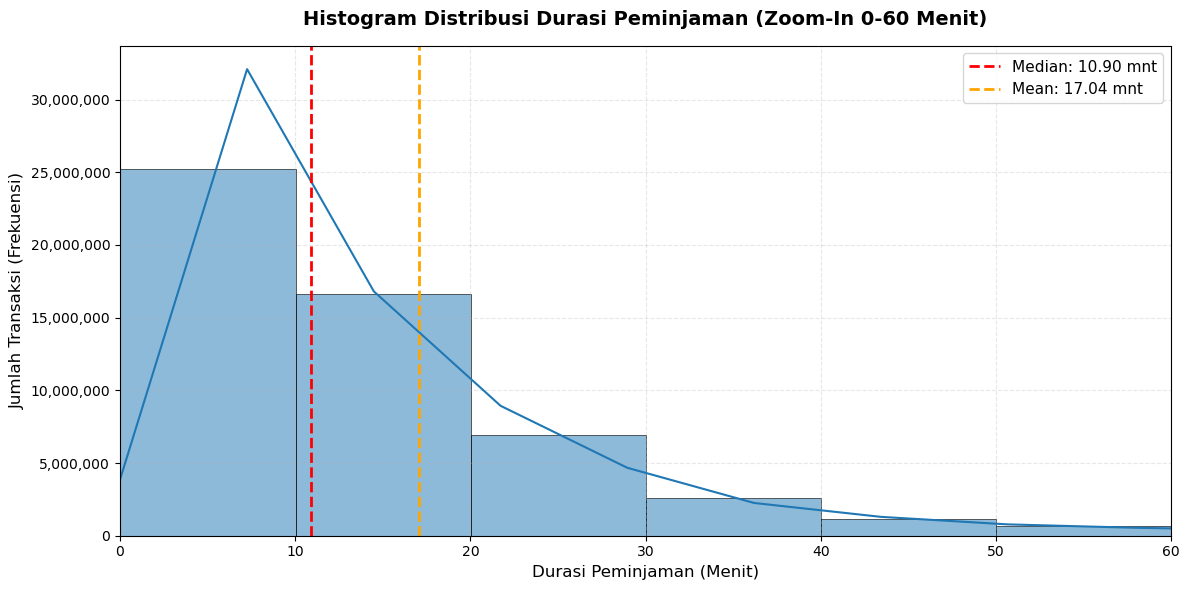

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.histplot(
    data=dfc, 
    x='tripduration_menit', 
    bins=144,          
    kde=True,          
    color='#1f77b4', 
    edgecolor='black'
)

plt.xlim(0, 60) 

plt.axvline(dfc['tripduration_menit'].median(), color='red', linestyle='--', linewidth=2, label=f"Median: {dfc['tripduration_menit'].median():.2f} mnt")
plt.axvline(dfc['tripduration_menit'].mean(), color='orange', linestyle='--', linewidth=2, label=f"Mean: {dfc['tripduration_menit'].mean():.2f} mnt")

plt.title('Histogram Distribusi Durasi Peminjaman (Zoom-In 0-60 Menit)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Durasi Peminjaman (Menit)', fontsize=12)
plt.ylabel('Jumlah Transaksi (Frekuensi)', fontsize=12)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

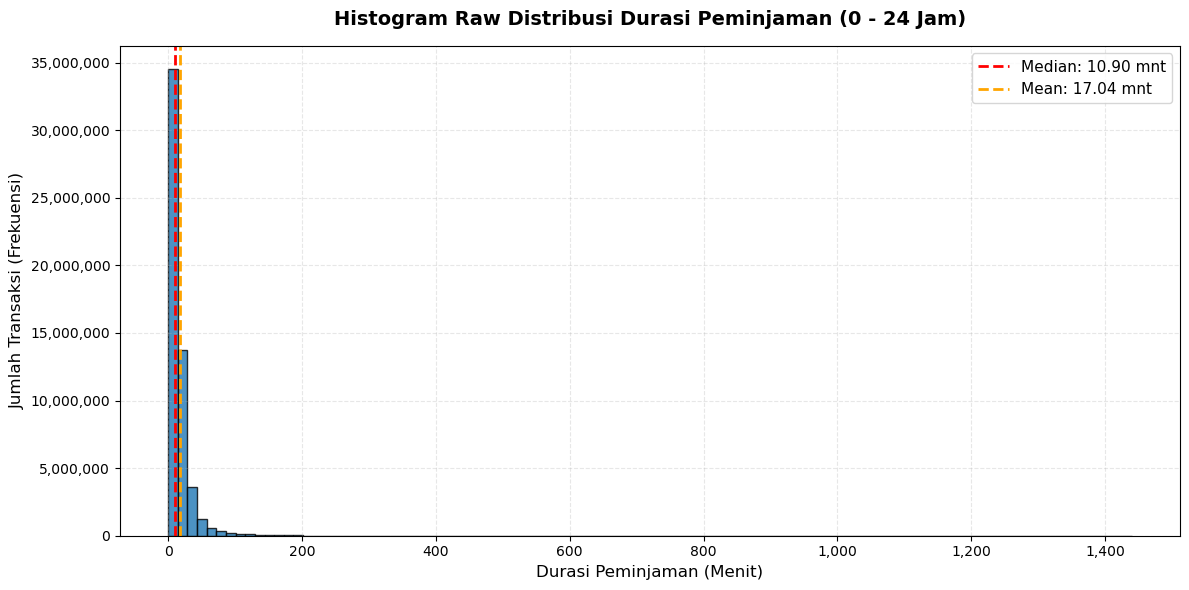

In [17]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))


plt.hist(
    dfc['tripduration_menit'], 
    bins=100, 
    color='#1f77b4', 
    edgecolor='black',
    alpha=0.8
)

plt.axvline(dfc['tripduration_menit'].median(), color='red', linestyle='--', linewidth=2, label=f"Median: {dfc['tripduration_menit'].median():.2f} mnt")
plt.axvline(dfc['tripduration_menit'].mean(), color='orange', linestyle='--', linewidth=2, label=f"Mean: {dfc['tripduration_menit'].mean():.2f} mnt")

plt.title('Histogram Raw Distribusi Durasi Peminjaman (0 - 24 Jam)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Durasi Peminjaman (Menit)', fontsize=12)
plt.ylabel('Jumlah Transaksi (Frekuensi)', fontsize=12)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
jumlah_anomali = (dfc['tripduration'] < 120).sum()
total_rows = len(dfc)
persentase = (jumlah_anomali / total_rows) * 100

print(f"Jumlah data yang kurang dari 2 menit: {jumlah_anomali:,} baris")


Jumlah data yang kurang dari 2 menit: 1,486,797 baris
Persentase data            : 2.7088% dari total data


# from_station_id and from_station_name

In [49]:
# skip this, after some trial and error through looping process and analisis it's unreliabel. and hard to debug.

# start_lat, start_lng, end_lat and end_lng

In [64]:
import pandas as pd
kolom_analisis = ['from_station_name','start_lat', 'start_lng', 'end_lat', 'end_lng']
df = pd.read_parquet('divvy_total_2013_2026_final_clean.parquet', columns=kolom_analisis)

df.head()

,from_station_name,start_lat,start_lng,end_lat,end_lng
0,Michigan Ave & Oak St,NaN,NaN,NaN,NaN
1,Racine Ave & Congress Pkwy,NaN,NaN,NaN,NaN
2,Racine Ave & Congress Pkwy,NaN,NaN,NaN,NaN
3,Loomis St & Taylor St,NaN,NaN,NaN,NaN
4,Loomis St & Taylor St,NaN,NaN,NaN,NaN


In [66]:
df.isnull().sum()

from_station_name     5095133
start_lat            21239924
start_lng            21239924
end_lat              21247475
end_lng              21247475
dtype: int64

In [67]:
len(df)

54887538

In [68]:
54887538 -  21239924

33647614

In [72]:
df.tail()

,from_station_name,start_lat,start_lng,end_lat,end_lng
54887533,HQ QR,41.8899,-87.6803,41.8899,-87.6803
54887534,Rush St & Superior St,41.8958,-87.6259,41.9542,-87.6544
54887535,Clark St & Lincoln Ave,41.9157,-87.6346,41.9035,-87.6677
54887536,Franklin St & Illinois St,41.8910,-87.6355,41.8868,-87.6223
54887537,Dearborn St & Erie St,41.8940,-87.6293,41.9010,-87.6238


In [78]:
dfc = df.copy()

In [138]:
# Menerapkan pembulatan 3 desimal untuk mengunci realitas area stasiun
dfc['start_lat_cluster'] = dfc['start_lat'].round(4)
dfc['start_lng_cluster'] = dfc['start_lng'].round(4)

dfc['end_lat_cluster'] = dfc['end_lat'].round(4)
dfc['end_lng_cluster'] = dfc['end_lng'].round(4)

In [139]:
dfc

,from_station_name,start_lat,start_lng,end_lat,end_lng,start_lat_cluster,start_lng_cluster,end_lat_cluster,end_lng_cluster
0,Michigan Ave & Oak St,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Racine Ave & Congress Pkwy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Racine Ave & Congress Pkwy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Loomis St & Taylor St,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Loomis St & Taylor St,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
54887533,HQ QR,41.8899,-87.6803,41.8899,-87.6803,41.8899,-87.6803,41.8899,-87.6803
54887534,Rush St & Superior St,41.8958,-87.6259,41.9542,-87.6544,41.8958,-87.6259,41.9542,-87.6544
54887535,Clark St & Lincoln Ave,41.9157,-87.6346,41.9035,-87.6677,41.9157,-87.6346,41.9035,-87.6677
54887536,Franklin St & Illinois St,41.8910,-87.6355,41.8868,-87.6223,41.8910,-87.6355,41.8868,-87.6223


In [144]:
dfc['start_lat_cluster'].nunique()

3011

In [148]:
dfc['start_lng_cluster'].nunique()

2466

In [150]:
total_stasiun = dfc[['start_lat_cluster', 'start_lng_cluster']].dropna().drop_duplicates().shape[0]

print(f"Total stasiun setelah di-rounding 4 desimal adalah: {total_stasiun}")

Total stasiun setelah di-rounding 4 desimal adalah: 64504


In [154]:
import pandas as pd
dfc['geo_start_area'] = dfc['start_lat_cluster'].astype(str) + "_" + dfc['start_lng_cluster'].astype(str)
hitung_transaksi = dfc.groupby('geo_start_area').agg(
    total_transaksi=('geo_start_area', 'size'),
    from_station_name=('from_station_name', lambda x: x.mode()[0] if not x.mode().empty else "E-Bike Dockless / Public Rack")
).reset_index()
hitung_transaksi = hitung_transaksi.sort_values(by='total_transaksi', ascending=False).reset_index(drop=True)

print("=== 10 Cluster Paling Ramai (Stasiun Utama) ===")
print(hitung_transaksi[['geo_start_area', 'from_station_name', 'total_transaksi']].head(10))

print("\n=== Analisis Cluster Sepi ===")
cluster_sepi = hitung_transaksi[hitung_transaksi['total_transaksi'] < 10]
print(f"Ada {len(cluster_sepi)} cluster sepi (kurang dari 10 transaksi) dari total {len(hitung_transaksi)} cluster.")

=== 10 Cluster Paling Ramai (Stasiun Utama) ===
     geo_start_area                   from_station_name  total_transaksi
0           nan_nan             Streeter Dr & Grand Ave         21239924
1   41.8923_-87.612             Streeter Dr & Grand Ave           344652
2   41.881_-87.6167   DuSable Lake Shore Dr & Monroe St           217126
3  41.9117_-87.6268  DuSable Lake Shore Dr & North Blvd           209397
4   41.901_-87.6238               Michigan Ave & Oak St           190708
5  41.9263_-87.6308                 Theater on the Lake           164673
6   41.881_-87.6241                     Millennium Park           163548
7   41.903_-87.6313                   Clark St & Elm St           163360
8  41.8892_-87.6385            Kingsbury St & Kinzie St           162776
9  41.9121_-87.6347               Wells St & Concord Ln           159146

=== Analisis Cluster Sepi ===
Ada 42665 cluster sepi (kurang dari 10 transaksi) dari total 64505 cluster.


# usetype

In [2]:
import pandas as pd
kolom_analisis = ['usertype']
df = pd.read_parquet('divvy_total_2013_2026_final_clean.parquet', columns=kolom_analisis)

df.head()

,usertype
0,casual
1,casual
2,casual
3,casual
4,casual


In [4]:
dfc = df.copy()

In [8]:
dfc["usertype"].unique()

array(['casual', 'member'], dtype=object)

In [16]:
dfc["usertype"].value_counts()

usertype
member    0.667435
casual    0.332565
Name: proportion, dtype: float64

In [18]:
dfc["usertype"].value_counts(1)

usertype
member    0.667435
casual    0.332565
Name: proportion, dtype: float64

In [20]:
df['usertype'].value_counts(normalize=True)

usertype
member    0.667435
casual    0.332565
Name: proportion, dtype: float64

# Gender

In [23]:
import pandas as pd
kolom_analisis = ['gender']
df = pd.read_parquet('divvy_total_2013_2026_final_clean.parquet', columns=kolom_analisis)

df.head()

,gender
0,nan
1,nan
2,nan
3,nan
4,nan


In [25]:
dfc = df.copy()

In [27]:
dfc["gender"].value_counts()

gender
nan       38540758
Male      12234756
Female     4112024
Name: count, dtype: int64

# Birthyear

In [32]:
import pandas as pd
kolom_analisis = ['birthyear']
df = pd.read_parquet('divvy_total_2013_2026_final_clean.parquet', columns=kolom_analisis)

df.head()

,birthyear
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN


In [34]:
dfc = df.copy()

In [36]:
dfc.value_counts()

birthyear
1989.0       919298
1988.0       833274
1990.0       830614
1987.0       805677
1986.0       768481
              ...  
1932.0           14
1910.0            7
1928.0            3
1925.0            2
1911.0            1
Name: count, Length: 89, dtype: int64

In [50]:
dfc.max()

birthyear    2004.0
dtype: float64

In [40]:
dfc.min()

birthyear    1910.0
dtype: float64

In [52]:
print("most member by age")
dfc.value_counts().head()

most member by age


birthyear
1989.0       919298
1988.0       833274
1990.0       830614
1987.0       805677
1986.0       768481
Name: count, dtype: int64

In [60]:
print("least member by age")
dfc.value_counts().tail(30)

least member by age


birthyear
1943.0       2257
1939.0       2247
1940.0       1805
1918.0       1803
1941.0       1694
1942.0       1681
2003.0       1065
1921.0        981
1938.0        750
1934.0        568
1931.0        348
1930.0        242
1915.0        153
1929.0         85
1916.0         83
1912.0         57
1933.0         55
1935.0         50
1920.0         32
2004.0         31
1927.0         23
1936.0         19
1923.0         16
1922.0         16
1937.0         14
1932.0         14
1910.0          7
1928.0          3
1925.0          2
1911.0          1
Name: count, dtype: int64

# rideable_type

In [63]:
import pandas as pd
kolom_analisis = ['rideable_type']
df = pd.read_parquet('divvy_total_2013_2026_final_clean.parquet', columns=kolom_analisis)

df.head()

,rideable_type
0,nan
1,nan
2,nan
3,nan
4,nan


In [65]:
dfc = df.copy()

In [67]:
dfc.value_counts()

rideable_type   
nan                 21239924
electric_bike       16175008
classic_bike        13812384
docked_bike          3515886
electric_scooter      144336
Name: count, dtype: int64

In [73]:
# ration tanpa nan
print("Rideable type ration exlude nan")
ratio_armada = dfc[dfc['rideable_type'] != 'nan']['rideable_type'].value_counts(normalize=True)

print(ratio_armada)

Rideable type ration exlude nan
rideable_type
electric_bike       0.480718
classic_bike        0.410501
docked_bike         0.104491
electric_scooter    0.004290
Name: proportion, dtype: float64


# Multivariate

## Apakah ada perbedaan waktu (bulan, hari, jam) penggunaan layanan antara casual dan member?

In [1]:
import pandas as pd
kolom_analisis = ['starttime', 'usertype']
df = pd.read_parquet('divvy_total_2013_2026_final_clean.parquet', columns=kolom_analisis)

df.head()

,starttime,usertype
0,2013-06-27 12:11:00,casual
1,2013-06-27 14:44:00,casual
2,2013-06-27 14:58:00,casual
3,2013-06-27 15:06:00,casual
4,2013-06-27 15:13:00,casual


In [2]:
dfc = df.copy()

In [3]:
dfc.tail()

,starttime,usertype
54887533,2020-03-10 10:40:06,casual
54887534,2020-03-07 15:25:55,member
54887535,2020-03-01 13:12:38,casual
54887536,2020-03-07 18:02:45,member
54887537,2020-03-08 13:03:57,casual


In [4]:
dfc.isnull().sum()

starttime    0
usertype     0
dtype: int64

In [5]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54887538 entries, 0 to 54887537
Data columns (total 2 columns):
 #   Column     Dtype         
---  ------     -----         
 0   starttime  datetime64[ns]
 1   usertype   object        
dtypes: datetime64[ns](1), object(1)
memory usage: 837.5+ MB


In [49]:
dfc["month"] = dfc["starttime"].dt.month_name()
dfc["day"] = dfc["starttime"].dt.day_name()
dfc["hour"] = dfc["starttime"].dt.hour
dfc

,starttime,usertype,month,day,hour
0,2013-06-27 12:11:00,casual,June,Thursday,12
1,2013-06-27 14:44:00,casual,June,Thursday,14
2,2013-06-27 14:58:00,casual,June,Thursday,14
3,2013-06-27 15:06:00,casual,June,Thursday,15
4,2013-06-27 15:13:00,casual,June,Thursday,15
...,...,...,...,...,...
54887533,2020-03-10 10:40:06,casual,March,Tuesday,10
54887534,2020-03-07 15:25:55,member,March,Saturday,15
54887535,2020-03-01 13:12:38,casual,March,Sunday,13
54887536,2020-03-07 18:02:45,member,March,Saturday,18


In [50]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54887538 entries, 0 to 54887537
Data columns (total 5 columns):
 #   Column     Dtype         
---  ------     -----         
 0   starttime  datetime64[ns]
 1   usertype   object        
 2   month      object        
 3   day        object        
 4   hour       int32         
dtypes: datetime64[ns](1), int32(1), object(3)
memory usage: 1.8+ GB


In [51]:
dfc.isnull().sum()

starttime    0
usertype     0
month        0
day          0
hour         0
dtype: int64

In [52]:
dfc["day"].unique()

array(['Thursday', 'Friday', 'Saturday', 'Sunday', 'Monday', 'Tuesday',
       'Wednesday'], dtype=object)

In [53]:
dfc["hour"].unique()

array([12, 14, 15, 19, 18, 20, 21, 22, 23,  0,  1,  2,  3,  5,  6,  7,  8,
        9, 10, 11, 13, 16, 17,  4])

## Monthly analysis

In [54]:
perbedaan_bulan = dfc.groupby(["usertype","month"]).size()

In [55]:
perbedaan_bulan

usertype  month    
casual    April        1078174
          August       3052963
          December      315916
          February      245955
          January       178452
          July         3193836
          June         2573281
          March         621747
          May          2090233
          November      716712
          October      1644169
          September    2542244
member    April        2673936
          August       4689650
          December     1541691
          February     1371557
          January      1278602
          July         4479635
          June         4054251
          March        2064236
          May          3700705
          November     2465615
          October      3877918
          September    4436060
dtype: int64

In [63]:
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
dfc["month"] = pd.Categorical(dfc["month"], categories=month_order, ordered=True)
perbedaan_bulan = dfc.groupby(["usertype", "month"]).size().reset_index(name="count")
print(perbedaan_bulan)

C:\Users\Bocah\AppData\Local\Temp\ipykernel_4412\3360758101.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  perbedaan_bulan = dfc.groupby(["usertype", "month"]).size().reset_index(name="count")


   usertype      month    count
0    casual    January   178452
1    casual   February   245955
2    casual      March   621747
3    casual      April  1078174
4    casual        May  2090233
5    casual       June  2573281
6    casual       July  3193836
7    casual     August  3052963
8    casual  September  2542244
9    casual    October  1644169
10   casual   November   716712
11   casual   December   315916
12   member    January  1278602
13   member   February  1371557
14   member      March  2064236
15   member      April  2673936
16   member        May  3700705
17   member       June  4054251
18   member       July  4479635
19   member     August  4689650
20   member  September  4436060
21   member    October  3877918
22   member   November  2465615
23   member   December  1541691


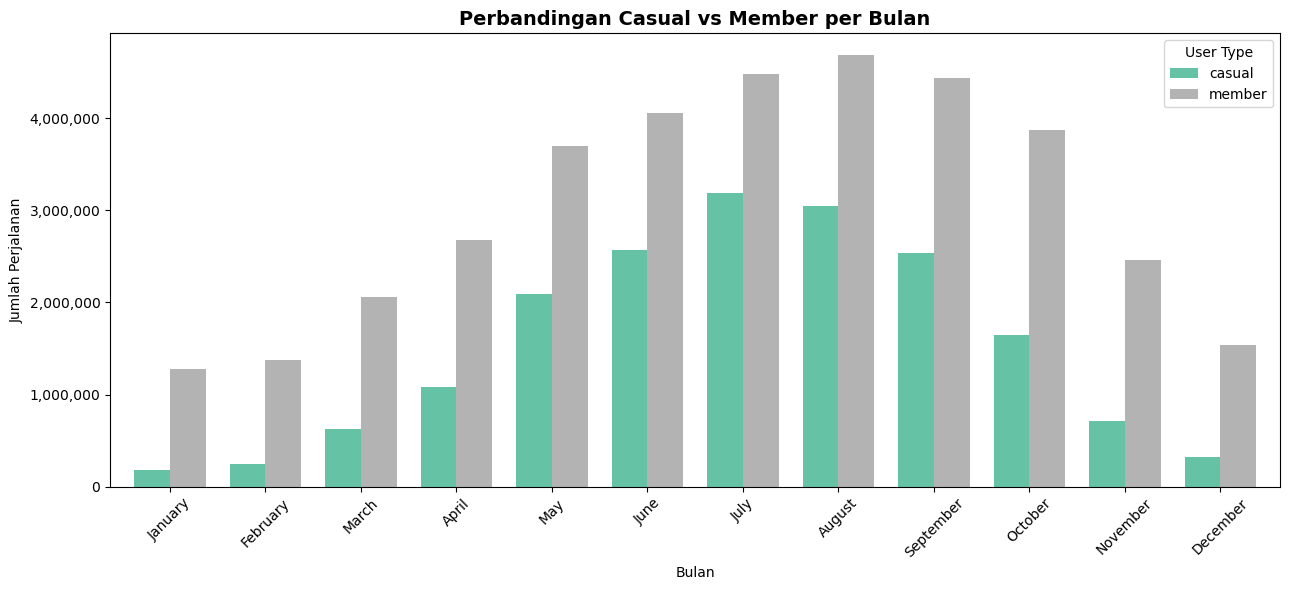

In [107]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
pivot = perbedaan_bulan.pivot(index="month", columns="usertype", values="count")

pivot.plot(
    kind="bar",
    figsize=(13, 6),
    width=0.75,
    colormap="Set2"
)

plt.title("Perbandingan Casual vs Member per Bulan", fontsize=14, fontweight="bold")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Perjalanan")
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.legend(title="User Type")
plt.tight_layout()
plt.show()

## Day of the week analysis

In [75]:
perbedaan_hari = dfc.groupby(["usertype","day"]).size()

In [76]:
perbedaan_hari

usertype  day      
casual    Friday       2597251
          Monday       2131859
          Saturday     4055253
          Sunday       3457825
          Thursday     2119760
          Tuesday      1927757
          Wednesday    1963977
member    Friday       5456910
          Monday       5354055
          Saturday     4349598
          Sunday       3858792
          Thursday     5838536
          Tuesday      5874712
          Wednesday    5901253
dtype: int64

In [81]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

dfc["day"] = pd.Categorical(dfc["day"], categories=day_order, ordered=True)

perbedaan_hari = dfc.groupby(["usertype", "day"]).size().reset_index(name="count")
print(perbedaan_hari)

C:\Users\Bocah\AppData\Local\Temp\ipykernel_4412\3015299719.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  perbedaan_hari = dfc.groupby(["usertype", "day"]).size().reset_index(name="count")


   usertype        day    count
0    casual     Monday  2131859
1    casual    Tuesday  1927757
2    casual  Wednesday  1963977
3    casual   Thursday  2119760
4    casual     Friday  2597251
5    casual   Saturday  4055253
6    casual     Sunday  3457825
7    member     Monday  5354055
8    member    Tuesday  5874712
9    member  Wednesday  5901253
10   member   Thursday  5838536
11   member     Friday  5456910
12   member   Saturday  4349598
13   member     Sunday  3858792


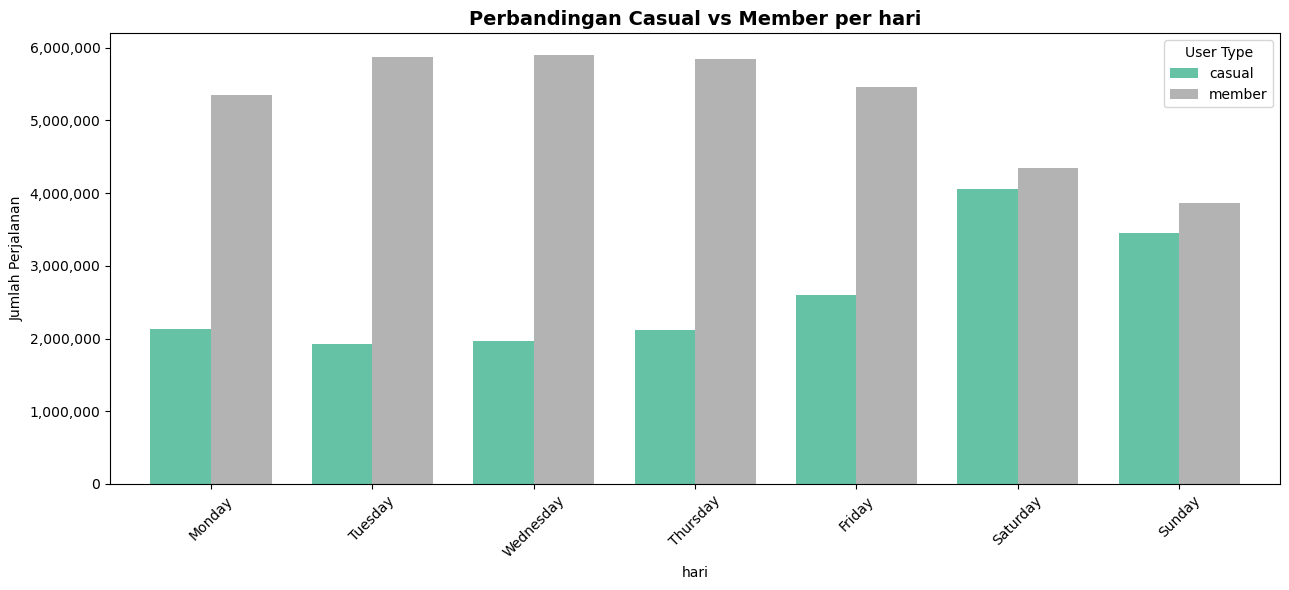

In [85]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
pivot = perbedaan_hari.pivot(index="day", columns="usertype", values="count")

pivot.plot(
    kind="bar",
    figsize=(13, 6),
    width=0.75,
    colormap="Set2"
)

plt.title("Perbandingan Casual vs Member per hari", fontsize=14, fontweight="bold")
plt.xlabel("hari")
plt.ylabel("Jumlah Perjalanan")
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.legend(title="User Type")
plt.tight_layout()
plt.show()

## hourly analisis

In [89]:
perbedaan_jam = dfc.groupby(["usertype","hour"]).size()

In [91]:
perbedaan_jam

usertype  hour
casual    0        293043
          1        193302
          2        121558
          3         67870
          4         49245
          5         78778
          6        185036
          7        345227
          8        506179
          9        594898
          10       823236
          11      1089447
          12      1284651
          13      1367845
          14      1431066
          15      1524455
          16      1629716
          17      1709095
          18      1460427
          19      1098504
          20       790569
          21       640583
          22       561088
          23       407864
member    0        290185
          1        175831
          2        102187
          3         65122
          4         81750
          5        351153
          6       1113241
          7       2282224
          8       2861433
          9       1673312
          10      1406624
          11      1686917
          12      1941096
          13      19023

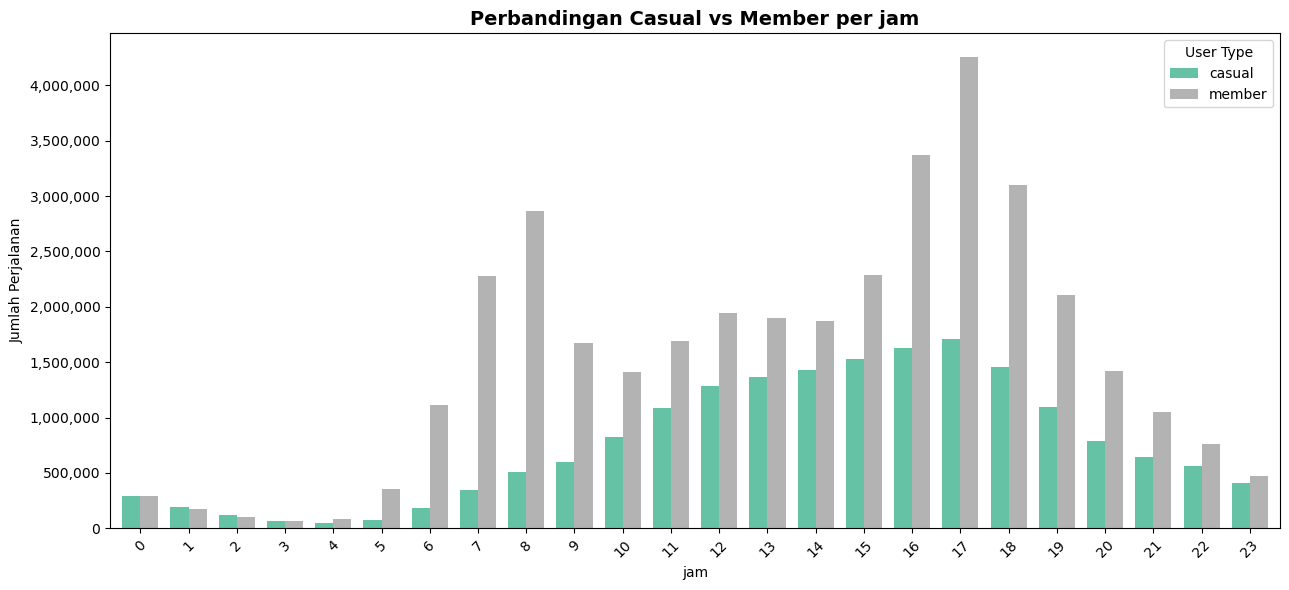

In [95]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
pivot = perbedaan_jam.unstack(level="usertype")

pivot.plot(
    kind="bar",
    figsize=(13, 6),
    width=0.75,
    colormap="Set2"
)

plt.title("Perbandingan Casual vs Member per jam", fontsize=14, fontweight="bold")
plt.xlabel("jam")
plt.ylabel("Jumlah Perjalanan")
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.legend(title="User Type")
plt.tight_layout()
plt.show()

# Apakah ada perbedaan waktu tripduration antara casual dan member?

In [112]:
import pandas as pd
kolom_analisis = ['usertype','tripduration']
df = pd.read_parquet('divvy_total_2013_2026_final_clean.parquet', columns=kolom_analisis)

df.head()

,usertype,tripduration
0,casual,316.0
1,casual,64.0
2,casual,433.0
3,casual,123.0
4,casual,852.0


In [114]:
dfc = df.copy()

In [116]:
dfc.isnull().sum()

usertype        0
tripduration    0
dtype: int64

In [126]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54887538 entries, 0 to 54887537
Data columns (total 2 columns):
 #   Column        Dtype  
---  ------        -----  
 0   usertype      object 
 1   tripduration  float64
dtypes: float64(1), object(1)
memory usage: 837.5+ MB


In [134]:
dfc["tripduration_minute"] = dfc["tripduration"] / 60

In [135]:
dfc

,usertype,tripduration,tripduration_minute
0,casual,316.0,5.266667
1,casual,64.0,1.066667
2,casual,433.0,7.216667
3,casual,123.0,2.050000
4,casual,852.0,14.200000
...,...,...,...
54887533,casual,1.0,0.016667
54887534,member,2888.0,48.133333
54887535,casual,1551.0,25.850000
54887536,member,633.0,10.550000


In [140]:
print("rata-rata penggunaan layanan casual vs member")
durasi_rata_rata = dfc.groupby("usertype")["tripduration_minute"].mean()
print(durasi_rata_rata)

rata-rata penggunaan layanan casual vs member
usertype
casual    26.255605
member    12.447767
Name: tripduration_minute, dtype: float64


In [146]:
print("median trip duration")
durasi_median = dfc.groupby("usertype")["tripduration_minute"].median()
print(durasi_median)

median trip duration
usertype
casual    16.35
member     9.25
Name: tripduration_minute, dtype: float64


In [144]:
# Mendapatkan ringkasan statistik deskriptif lengkap
dfc.groupby("usertype")["tripduration_minute"].describe()

,count,mean,std,min,25%,50%,75%,max
usertype,,,,,,,,
casual,18253682.0,26.255605,47.846228,0.016667,8.783333,16.35,28.633333,1440.00
member,36633856.0,12.447767,20.324742,0.016667,5.533333,9.25,15.416667,1439.95


# Apakah ada perbedaan durasi perjalanan berdasarkan bulan, hari, jam?

In [1]:
import pandas as pd
kolom_analisis = ['starttime','tripduration', 'usertype']
df = pd.read_parquet('divvy_total_2013_2026_final_clean.parquet', columns=kolom_analisis)

df.head()

,starttime,tripduration,usertype
0,2013-06-27 12:11:00,316.0,casual
1,2013-06-27 14:44:00,64.0,casual
2,2013-06-27 14:58:00,433.0,casual
3,2013-06-27 15:06:00,123.0,casual
4,2013-06-27 15:13:00,852.0,casual


In [2]:
dfc = df.copy()

In [3]:
dfc["month"] = dfc["starttime"].dt.month_name()
dfc["day"] = dfc["starttime"].dt.day_name()
dfc["hour"] = dfc["starttime"].dt.hour
dfc["tripduration_minute"] = dfc["tripduration"] / 60
dfc

,starttime,tripduration,usertype,month,day,hour,tripduration_minute
0,2013-06-27 12:11:00,316.0,casual,June,Thursday,12,5.266667
1,2013-06-27 14:44:00,64.0,casual,June,Thursday,14,1.066667
2,2013-06-27 14:58:00,433.0,casual,June,Thursday,14,7.216667
3,2013-06-27 15:06:00,123.0,casual,June,Thursday,15,2.050000
4,2013-06-27 15:13:00,852.0,casual,June,Thursday,15,14.200000
...,...,...,...,...,...,...,...
54887533,2020-03-10 10:40:06,1.0,casual,March,Tuesday,10,0.016667
54887534,2020-03-07 15:25:55,2888.0,member,March,Saturday,15,48.133333
54887535,2020-03-01 13:12:38,1551.0,casual,March,Sunday,13,25.850000
54887536,2020-03-07 18:02:45,633.0,member,March,Saturday,18,10.550000


In [4]:
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
dfc["month"] = pd.Categorical(dfc["month"], categories=month_order, ordered=True)
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dfc["day"] = pd.Categorical(dfc["day"], categories=day_order, ordered=True)
dfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54887538 entries, 0 to 54887537
Data columns (total 7 columns):
 #   Column               Dtype         
---  ------               -----         
 0   starttime            datetime64[ns]
 1   tripduration         float64       
 2   usertype             object        
 3   month                category      
 4   day                  category      
 5   hour                 int32         
 6   tripduration_minute  float64       
dtypes: category(2), datetime64[ns](1), float64(2), int32(1), object(1)
memory usage: 1.9+ GB


In [6]:
mounth_tripduration = dfc.groupby(["usertype", "month"], as_index=False)["tripduration_minute"].mean()

C:\Users\Bocah\AppData\Local\Temp\ipykernel_16820\2857936637.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mounth_tripduration = dfc.groupby(["usertype", "month"], as_index=False)["tripduration_minute"].mean()


In [8]:
mounth_tripduration

,usertype,month,tripduration_minute
0,casual,January,17.336383
1,casual,February,20.086849
2,casual,March,23.338367
3,casual,April,25.083755
4,casual,May,27.628117
5,casual,June,27.948753
6,casual,July,29.060938
7,casual,August,27.689522
8,casual,September,25.354946
9,casual,October,23.112022


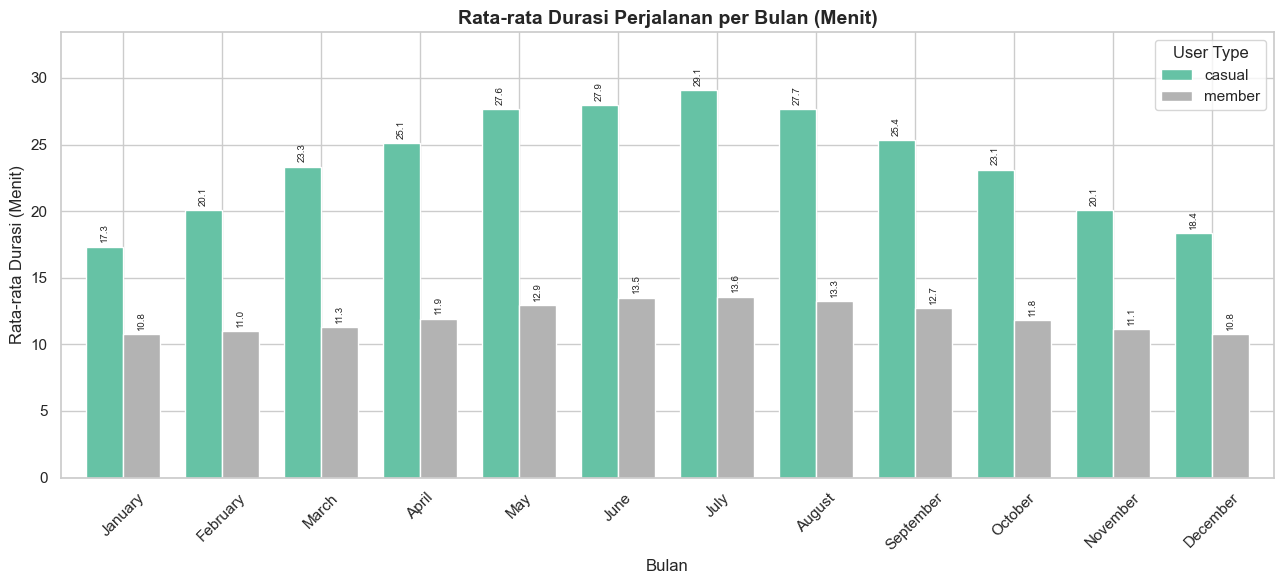

In [205]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pivot = mounth_tripduration.pivot(index="month", columns="usertype", values="tripduration_minute")

ax = pivot.plot(
    kind="bar",
    figsize=(13, 6),
    width=0.75,
    colormap="Set2"
)

# Label di atas batang (1 desimal cukup untuk menit)
for container in ax.containers:
    ax.bar_label(
        container,
        fmt=lambda x: f"{x:.1f}",
        label_type="edge",
        fontsize=7,
        padding=3,
        rotation=90
    )

ax.margins(y=0.15)
plt.title("Rata-rata Durasi Perjalanan per Bulan (Menit)", fontsize=14, fontweight="bold")
plt.xlabel("Bulan")
plt.ylabel("Rata-rata Durasi (Menit)")
plt.xticks(rotation=45)
plt.legend(title="User Type")
plt.tight_layout()
plt.show()

In [9]:
weekly_tripduration = dfc.groupby(["usertype", "day"], as_index=False)["tripduration_minute"].mean()

C:\Users\Bocah\AppData\Local\Temp\ipykernel_16820\522310917.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weekly_tripduration = dfc.groupby(["usertype", "day"], as_index=False)["tripduration_minute"].mean()


In [10]:
weekly_tripduration

,usertype,day,tripduration_minute
0,casual,Monday,26.078823
1,casual,Tuesday,23.626685
2,casual,Wednesday,22.966144
3,casual,Thursday,23.197845
4,casual,Friday,24.985511
5,casual,Saturday,28.777929
6,casual,Sunday,29.568965
7,member,Monday,12.070435
8,member,Tuesday,11.962486
9,member,Wednesday,11.978485


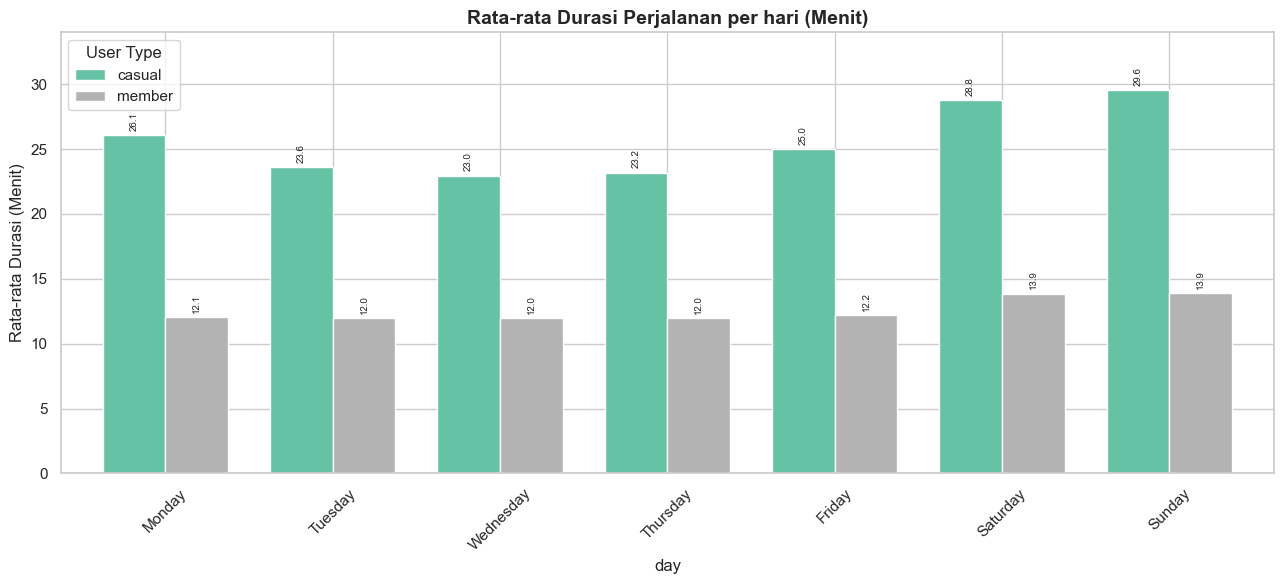

In [211]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pivot = weekly_tripduration.pivot(index="day", columns="usertype", values="tripduration_minute")

ax = pivot.plot(
    kind="bar",
    figsize=(13, 6),
    width=0.75,
    colormap="Set2"
)

# Label di atas batang (1 desimal cukup untuk menit)
for container in ax.containers:
    ax.bar_label(
        container,
        fmt=lambda x: f"{x:.1f}",
        label_type="edge",
        fontsize=7,
        padding=3,
        rotation=90
    )

ax.margins(y=0.15)
plt.title("Rata-rata Durasi Perjalanan per hari (Menit)", fontsize=14, fontweight="bold")
plt.xlabel("day")
plt.ylabel("Rata-rata Durasi (Menit)")
plt.xticks(rotation=45)
plt.legend(title="User Type")
plt.tight_layout()
plt.show()

## hourly

In [17]:
hour_tripduration = dfc.groupby(["usertype", "hour"], as_index=False)["tripduration_minute"].mean()

In [19]:
hour_tripduration

,usertype,hour,tripduration_minute
0,casual,0,24.021154
1,casual,1,24.631586
2,casual,2,24.497158
3,casual,3,24.492508
4,casual,4,21.639646
5,casual,5,18.606415
6,casual,6,17.480620
7,casual,7,17.712735
8,casual,8,20.015364
9,casual,9,26.149127


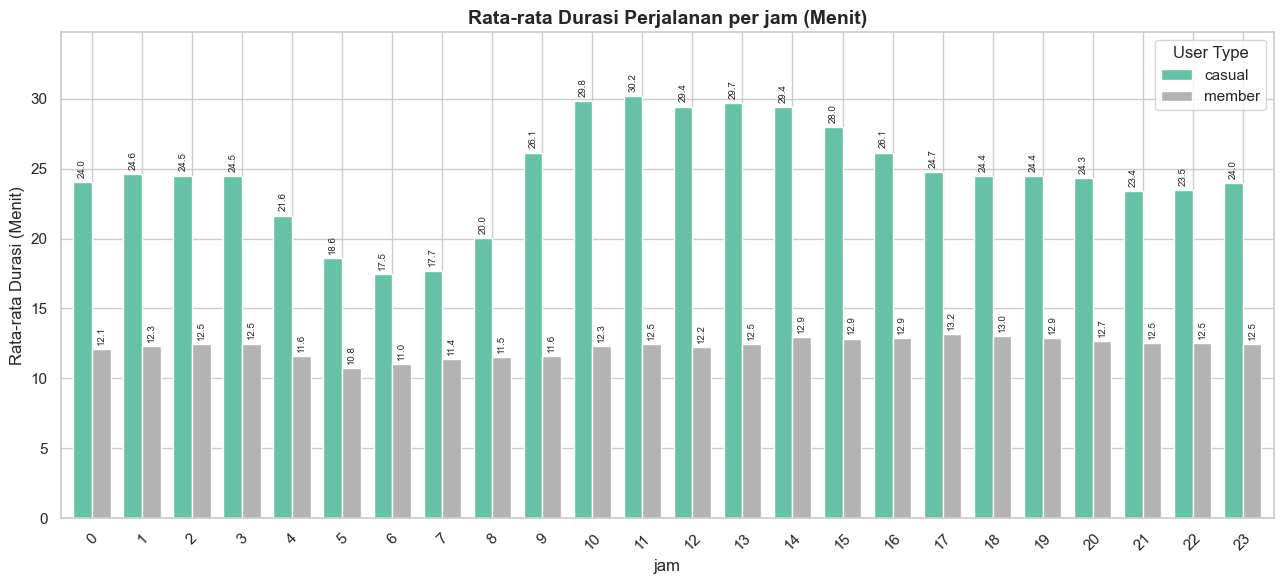

In [216]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pivot = hour_tripduration.pivot(index="hour", columns="usertype", values="tripduration_minute")

ax = pivot.plot(
    kind="bar",
    figsize=(13, 6),
    width=0.75,
    colormap="Set2"
)

# Label di atas batang (1 desimal cukup untuk menit)
for container in ax.containers:
    ax.bar_label(
        container,
        fmt=lambda x: f"{x:.1f}",
        label_type="edge",
        fontsize=7,
        padding=3,
        rotation=90
    )

ax.margins(y=0.15)
plt.title("Rata-rata Durasi Perjalanan per jam (Menit)", fontsize=14, fontweight="bold")
plt.xlabel("jam")
plt.ylabel("Rata-rata Durasi (Menit)")
plt.xticks(rotation=45)
plt.legend(title="User Type")
plt.tight_layout()
plt.show()

# Apakah ada perbedaan antara stasiun/wilayah yang sering di datang antara casual dan member?

In [247]:
import pandas as pd
kolom_analisis = ['start_lat', 'start_lng', 'end_lat', 'end_lng', 'usertype']
df = pd.read_parquet('divvy_total_2013_2026_final_clean.parquet', columns=kolom_analisis)

df.head()

,start_lat,start_lng,end_lat,end_lng,usertype
0,NaN,NaN,NaN,NaN,casual
1,NaN,NaN,NaN,NaN,casual
2,NaN,NaN,NaN,NaN,casual
3,NaN,NaN,NaN,NaN,casual
4,NaN,NaN,NaN,NaN,casual


In [248]:
dfc = df.copy()

In [249]:
dfc.isnull().sum()

start_lat    21239924
start_lng    21239924
end_lat      21247475
end_lng      21247475
usertype            0
dtype: int64

## analisis perbedaan jarak member vs casual (approx)

In [253]:
dfc = dfc.dropna(subset=['start_lat', 'start_lng', 'end_lat', 'end_lng'])

In [255]:
dfc.isnull().sum()

start_lat    0
start_lng    0
end_lat      0
end_lng      0
usertype     0
dtype: int64

In [257]:
dfc.tail()

,start_lat,start_lng,end_lat,end_lng,usertype
54887533,41.8899,-87.6803,41.8899,-87.6803,casual
54887534,41.8958,-87.6259,41.9542,-87.6544,member
54887535,41.9157,-87.6346,41.9035,-87.6677,casual
54887536,41.8910,-87.6355,41.8868,-87.6223,member
54887537,41.8940,-87.6293,41.9010,-87.6238,casual


In [259]:
import numpy as np

def hitung_jarak_haversine(lon1, lat1, lon2, lat2):
    # 1. Konversi koordinat dari derajat ke radian
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    
    # 2. Hitung selisih koordinat antar titik
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    
    # 3. Masukkan ke Rumus Utama Haversine
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    # 4. Kalikan dengan konstanta radius bumi (6367 kilometer)
    radius_bumi = 6367
    jarak_km = radius_bumi * c
    return jarak_km

# 5. Terapkan fungsi langsung ke DataFrame untuk membuat kolom baru 'jarak_km'
dfc['jarak_km'] = hitung_jarak_haversine(
    dfc['start_lng'], dfc['start_lat'], 
    dfc['end_lng'], dfc['end_lat']
)


print(dfc[['start_lat', 'start_lng', 'end_lat', 'end_lng', 'usertype', 'jarak_km']].tail())

          start_lat  start_lng  end_lat  end_lng usertype  jarak_km
54887533    41.8899   -87.6803  41.8899 -87.6803   casual  0.000000
54887534    41.8958   -87.6259  41.9542 -87.6544   member  6.904254
54887535    41.9157   -87.6346  41.9035 -87.6677   casual  3.054678
54887536    41.8910   -87.6355  41.8868 -87.6223   member  1.187545
54887537    41.8940   -87.6293  41.9010 -87.6238   casual  0.901140


In [260]:
dfc

,start_lat,start_lng,end_lat,end_lng,usertype,jarak_km
21239924,41.8964,-87.6610,41.9322,-87.6586,member,3.983226
21239925,41.9244,-87.7154,41.9306,-87.7238,member,0.978258
21239926,41.8945,-87.6179,41.8679,-87.6230,member,2.985893
21239927,41.9030,-87.6975,41.8992,-87.6722,member,2.134752
21239928,41.8902,-87.6262,41.9695,-87.6547,casual,9.121778
...,...,...,...,...,...,...
54887533,41.8899,-87.6803,41.8899,-87.6803,casual,0.000000
54887534,41.8958,-87.6259,41.9542,-87.6544,member,6.904254
54887535,41.9157,-87.6346,41.9035,-87.6677,casual,3.054678
54887536,41.8910,-87.6355,41.8868,-87.6223,member,1.187545


In [261]:
#kita buang angka yang tidak makesense besarnya, simply kerusakan gps terjadi itu.
dfc = dfc[dfc['jarak_km'] < 50]

In [264]:
jarak_dfc = dfc.groupby("usertype")["jarak_km"].describe()

In [265]:
jarak_dfc

,count,mean,std,min,25%,50%,75%,max
usertype,,,,,,,,
casual,12920469.0,2.159304,2.018402,0.0,0.873458,1.636451,2.858100,48.898078
member,20719525.0,2.148301,1.914432,0.0,0.878115,1.560873,2.813103,48.658875


In [271]:
len(dfc)

33639994

In [273]:
print("round trip dimana sepeda yang digunakan di kembalikan di stasiun yang sama")
print(dfc[dfc['jarak_km'] == 0].groupby('usertype').size() / dfc.groupby('usertype').size() * 100)

round trip dimana sepeda yang digunakan di kembalikan di stasiun yang sama
usertype
casual    9.437320
member    4.000183
dtype: float64


In [275]:
dfc

,start_lat,start_lng,end_lat,end_lng,usertype,jarak_km
21239924,41.8964,-87.6610,41.9322,-87.6586,member,3.983226
21239925,41.9244,-87.7154,41.9306,-87.7238,member,0.978258
21239926,41.8945,-87.6179,41.8679,-87.6230,member,2.985893
21239927,41.9030,-87.6975,41.8992,-87.6722,member,2.134752
21239928,41.8902,-87.6262,41.9695,-87.6547,casual,9.121778
...,...,...,...,...,...,...
54887533,41.8899,-87.6803,41.8899,-87.6803,casual,0.000000
54887534,41.8958,-87.6259,41.9542,-87.6544,member,6.904254
54887535,41.9157,-87.6346,41.9035,-87.6677,casual,3.054678
54887536,41.8910,-87.6355,41.8868,-87.6223,member,1.187545


## top tempat/stasiun member vs casual

In [278]:
# Duplikat dataframe agar aman
df_geo_top = dfc.copy()

# Bulatkan koordinat start ke 3 desimal
df_geo_top['start_lat_round'] = df_geo_top['start_lat'].round(3)
df_geo_top['start_lng_round'] = df_geo_top['start_lng'].round(3)

In [280]:
# Hitung total perjalanan untuk setiap kombinasi usertype dan koordinat stasiun
stasiun_ramai = df_geo_top.groupby(
    ['usertype', 'start_lat_round', 'start_lng_round']
).size().reset_index(name='total_perjalanan')

In [282]:

top_10_casual = stasiun_ramai[stasiun_ramai['usertype'] == 'casual'].sort_values(
    by='total_perjalanan', ascending=False
).head(10)
top_10_member = stasiun_ramai[stasiun_ramai['usertype'] == 'member'].sort_values(
    by='total_perjalanan', ascending=False
).head(10)

# Tampilkan Hasilnya
print("=== TOP 10 STASIUN AWAL CASUAL ===")
print(top_10_casual)

print("\n=== TOP 10 STASIUN AWAL MEMBER ===")
print(top_10_member)

=== TOP 10 STASIUN AWAL CASUAL ===
     usertype  start_lat_round  start_lng_round  total_perjalanan
3009   casual           41.892          -87.612            317150
2450   casual           41.881          -87.617            191237
2443   casual           41.881          -87.624            143021
3384   casual           41.901          -87.624            141417
3733   casual           41.912          -87.627            132600
4118   casual           41.926          -87.631            106268
1968   casual           41.867          -87.615            104914
2768   casual           41.887          -87.613             89815
3728   casual           41.912          -87.635             80297
1993   casual           41.868          -87.623             78318

=== TOP 10 STASIUN AWAL MEMBER ===
      usertype  start_lat_round  start_lng_round  total_perjalanan
8455    member           41.883          -87.641            185265
9820    member           41.912          -87.635            126806
87

In [288]:
# Bulatkan juga koordinat tujuannya
df_geo_top['end_lat_round'] = df_geo_top['end_lat'].round(3)
df_geo_top['end_lng_round'] = df_geo_top['end_lng'].round(3)

# Hitung kombinasi rute terpopuler
rute_ramai = df_geo_top.groupby(
    ['usertype', 'start_lat_round', 'start_lng_round', 'end_lat_round', 'end_lng_round']
).size().reset_index(name='total_rute')

print("=== TOP RUTE CASUAL ===")
print(rute_ramai[rute_ramai['usertype'] == 'casual'].sort_values(by='total_rute', ascending=False).head(5))
print("=== TOP RUTE MEMBER ===")
print(rute_ramai[rute_ramai['usertype'] == 'member'].sort_values(by='total_rute', ascending=False).head(5))

=== TOP RUTE CASUAL ===
       usertype  start_lat_round  start_lng_round  end_lat_round  \
298179   casual           41.892          -87.612         41.892   
196993   casual           41.881          -87.617         41.881   
197186   casual           41.881          -87.617         41.892   
358559   casual           41.901          -87.624         41.901   
195770   casual           41.881          -87.624         41.881   

        end_lng_round  total_rute  
298179        -87.612       60153  
196993        -87.617       42113  
197186        -87.612       29160  
358559        -87.624       27410  
195770        -87.624       24978  
=== TOP RUTE MEMBER ===
       usertype  start_lat_round  start_lng_round  end_lat_round  \
684490   member           41.790          -87.600         41.790   
680363   member           41.785          -87.601         41.794   
680346   member           41.785          -87.601         41.791   
689078   member           41.794          -87.601      

In [286]:
# 1. Pastikan koordinat akhir sudah dibulatkan ke 3 desimal
df_geo_top['end_lat_round'] = df_geo_top['end_lat'].round(3)
# Menggunakan 'end_lng' jika kolom aslimu adalah end_lng, atau sesuaikan dengan penamaan datamu (misal end_lng)
df_geo_top['end_lng_round'] = df_geo_top['end_lng'].round(3)

# 2. Hitung total kedatangan untuk setiap kombinasi usertype dan koordinat stasiun akhir
stasiun_akhir_ramai = df_geo_top.groupby(
    ['usertype', 'end_lat_round', 'end_lng_round']
).size().reset_index(name='total_kedatangan')

# 3. Pisahkan 10 teratas untuk Casual
top_10_end_casual = stasiun_akhir_ramai[stasiun_akhir_ramai['usertype'] == 'casual'].sort_values(
    by='total_kedatangan', ascending=False
).head(10)

# 4. Pisahkan 10 teratas untuk Member
top_10_end_member = stasiun_akhir_ramai[stasiun_akhir_ramai['usertype'] == 'member'].sort_values(
    by='total_kedatangan', ascending=False
).head(10)

# 5. Tampilkan Hasilnya
print("=== TOP 10 STASIUN AKHIR CASUAL ===")
print(top_10_end_casual)

print("\n=== TOP 10 STASIUN AKHIR MEMBER ===")
print(top_10_end_member)

=== TOP 10 STASIUN AKHIR CASUAL ===
     usertype  end_lat_round  end_lng_round  total_kedatangan
3819   casual         41.892        -87.612            333591
3200   casual         41.881        -87.617            177795
3194   casual         41.881        -87.624            151306
4737   casual         41.912        -87.627            149722
4258   casual         41.901        -87.624            147764
5260   casual         41.926        -87.631            114811
2552   casual         41.867        -87.615            100867
3538   casual         41.887        -87.613             80717
4730   casual         41.912        -87.635             78711
2583   casual         41.868        -87.623             75189

=== TOP 10 STASIUN AKHIR MEMBER ===
      usertype  end_lat_round  end_lng_round  total_kedatangan
10693   member         41.883        -87.641            213418
11043   member         41.889        -87.639            140907
11799   member         41.903        -87.631            

In [290]:
import pandas as pd

# 1. Gabungkan tabel top casual dan top member secara vertikal (ditumpuk)
top_stasiun_gabungan = pd.concat([top_10_casual, top_10_member], ignore_index=True)

# 2. Eksport hasil gabungan tersebut menjadi satu file CSV
top_stasiun_gabungan.to_csv('top_stasiun_awal.csv', index=False)

print("File 'top_stasiun_awal.csv' berhasil dibuat dan siap diimport ke Tableau!")
# Intip isi tabel gabungannya
print(top_stasiun_gabungan)

File 'top_stasiun_awal.csv' berhasil dibuat dan siap diimport ke Tableau!
   usertype  start_lat_round  start_lng_round  total_perjalanan
0    casual           41.892          -87.612            317150
1    casual           41.881          -87.617            191237
2    casual           41.881          -87.624            143021
3    casual           41.901          -87.624            141417
4    casual           41.912          -87.627            132600
5    casual           41.926          -87.631            106268
6    casual           41.867          -87.615            104914
7    casual           41.887          -87.613             89815
8    casual           41.912          -87.635             80297
9    casual           41.868          -87.623             78318
10   member           41.883          -87.641            185265
11   member           41.912          -87.635            126806
12   member           41.889          -87.639            125172
13   member           41.903  

In [292]:
# Gabungkan top stasiun akhir (menggunakan variabel dari kode stasiun akhirmu)
top_stasiun_akhir_gabungan = pd.concat([top_10_end_casual, top_10_end_member], ignore_index=True)

# Eksport ke CSV
top_stasiun_akhir_gabungan.to_csv('top_stasiun_akhir.csv', index=False)

print("File 'top_stasiun_akhir.csv' juga berhasil dibuat!")

File 'top_stasiun_akhir.csv' juga berhasil dibuat!


In [294]:
import pandas as pd

# 1. Ambil Top 50 rute terpopuler untuk masing-masing kategori
top_rute_casual = rute_ramai[rute_ramai['usertype'] == 'casual'].sort_values(by='total_rute', ascending=False).head(50)
top_rute_member = rute_ramai[rute_ramai['usertype'] == 'member'].sort_values(by='total_rute', ascending=False).head(50)

# 2. Gabungkan secara vertikal
top_rute_gabungan = pd.concat([top_rute_casual, top_rute_member], ignore_index=True)

# 3. Berikan ID unik untuk setiap rute (sangat penting untuk Tableau nanti)
top_rute_gabungan['rute_id'] = top_rute_gabungan.index + 1

# 4. Eksport ke CSV
top_rute_gabungan.to_csv('top_rute_perjalanan.csv', index=False)

print("File 'top_rute_perjalanan.csv' berhasil disimpan!")

File 'top_rute_perjalanan.csv' berhasil disimpan!


In [296]:
dfc

,start_lat,start_lng,end_lat,end_lng,usertype,jarak_km
21239924,41.8964,-87.6610,41.9322,-87.6586,member,3.983226
21239925,41.9244,-87.7154,41.9306,-87.7238,member,0.978258
21239926,41.8945,-87.6179,41.8679,-87.6230,member,2.985893
21239927,41.9030,-87.6975,41.8992,-87.6722,member,2.134752
21239928,41.8902,-87.6262,41.9695,-87.6547,casual,9.121778
...,...,...,...,...,...,...
54887533,41.8899,-87.6803,41.8899,-87.6803,casual,0.000000
54887534,41.8958,-87.6259,41.9542,-87.6544,member,6.904254
54887535,41.9157,-87.6346,41.9035,-87.6677,casual,3.054678
54887536,41.8910,-87.6355,41.8868,-87.6223,member,1.187545


In [298]:
top_rute_casual

,usertype,start_lat_round,start_lng_round,end_lat_round,end_lng_round,total_rute
298179,casual,41.892,-87.612,41.892,-87.612,60153
196993,casual,41.881,-87.617,41.881,-87.617,42113
197186,casual,41.881,-87.617,41.892,-87.612,29160
358559,casual,41.901,-87.624,41.901,-87.624,27410
195770,casual,41.881,-87.624,41.881,-87.624,24978
297933,casual,41.892,-87.612,41.881,-87.617,15459
254958,casual,41.887,-87.613,41.887,-87.613,14883
411489,casual,41.912,-87.627,41.912,-87.627,14610
466935,casual,41.926,-87.631,41.926,-87.631,13989
593415,casual,41.964,-87.638,41.964,-87.638,13792


# Apakah ada perbedaan jenis armada yang digunakan antara casual dan member?

In [348]:
import pandas as pd
kolom_analisis = ['usertype', 'rideable_type']
df = pd.read_parquet('divvy_total_2013_2026_final_clean.parquet', columns=kolom_analisis)

df.head()

,usertype,rideable_type
0,casual,nan
1,casual,nan
2,casual,nan
3,casual,nan
4,casual,nan


In [349]:
dfc = df.copy()

In [350]:
dfc = dfc[(dfc["rideable_type"] != "nan")]

In [351]:
dfc.value_counts()

usertype  rideable_type   
member    electric_bike       9853374
          classic_bike        8997548
casual    electric_bike       6321634
          classic_bike        4814836
member    docked_bike         1812625
casual    docked_bike         1703261
          electric_scooter      85214
member    electric_scooter      59122
Name: count, dtype: int64

In [358]:
df_hasil = dfc.groupby(["usertype", "rideable_type"]).size().reset_index(name='total_perjalanan')

In [359]:
df_hasil

,usertype,rideable_type,total_perjalanan
0,casual,classic_bike,4814836
1,casual,docked_bike,1703261
2,casual,electric_bike,6321634
3,casual,electric_scooter,85214
4,member,classic_bike,8997548
5,member,docked_bike,1812625
6,member,electric_bike,9853374
7,member,electric_scooter,59122


In [360]:
df_hasil.value_counts()

usertype  rideable_type     total_perjalanan
casual    classic_bike      4814836             1
          docked_bike       1703261             1
          electric_bike     6321634             1
          electric_scooter  85214               1
member    classic_bike      8997548             1
          docked_bike       1812625             1
          electric_bike     9853374             1
          electric_scooter  59122               1
Name: count, dtype: int64

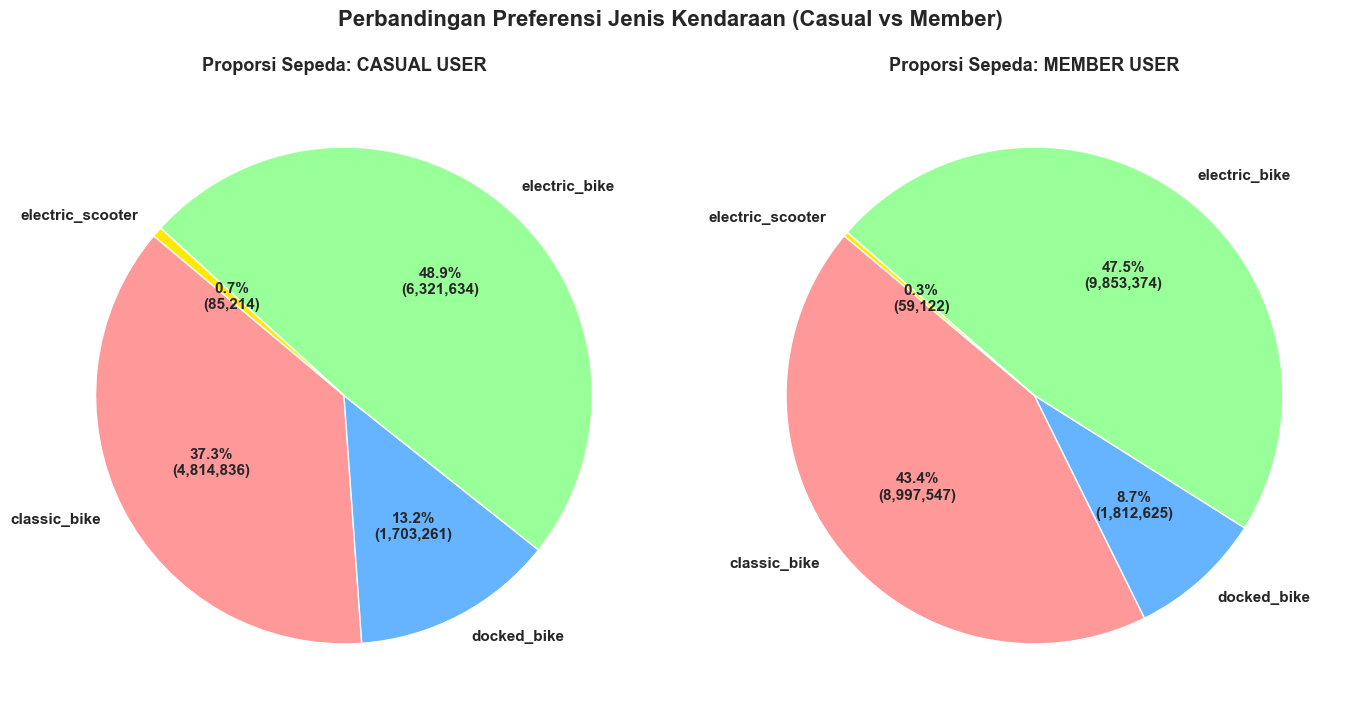

In [346]:
import matplotlib.pyplot as plt

# 1. Pisahkan data untuk masing-masing usertype
data_casual = df_hasil[df_hasil['usertype'] == 'casual']
data_member = df_hasil[df_hasil['usertype'] == 'member']

# 2. Siapkan kanvas grafik (1 baris, 2 kolom)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# 3. Fungsi kustom untuk menampilkan nominal angka dan persentase sekaligus di dalam lingkaran
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        # Format tulisan: Persentase% \n (Nominal Angka Berformat Ribuan)
        return f'{pct:.1f}%\n({val:,})'
    return my_autopct

# 4. PIE CHART 1: CASUAL USER (Kiri)
ax1.pie(
    data_casual['total_perjalanan'], 
    labels=data_casual['rideable_type'], 
    autopct=make_autopct(data_casual['total_perjalanan']),
    startangle=140, 
    colors=['#ff9999','#66b3ff','#99ff99', "#ffe900"],
    textprops={'fontsize': 11, 'weight': 'bold'}
)
ax1.set_title("Proporsi Sepeda: CASUAL USER", fontsize=13, fontweight='bold', pad=10)

# 5. PIE CHART 2: MEMBER USER (Kanan)
ax2.pie(
    data_member['total_perjalanan'], 
    labels=data_member['rideable_type'], 
    autopct=make_autopct(data_member['total_perjalanan']),
    startangle=140, 
    colors=['#ff9999','#66b3ff','#99ff99', "#ffe900"],
    textprops={'fontsize': 11, 'weight': 'bold'}
)
ax2.set_title("Proporsi Sepeda: MEMBER USER", fontsize=13, fontweight='bold', pad=10)

# 6. Tampilkan grafik secara rapi
plt.suptitle("Perbandingan Preferensi Jenis Kendaraan (Casual vs Member)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Gender

In [2]:
import pandas as pd
kolom_analisis = ['gender', 'tripduration']
df = pd.read_parquet('divvy_total_2013_2026_final_clean.parquet', columns=kolom_analisis)

df.head()

,gender,tripduration
0,nan,316.0
1,nan,64.0
2,nan,433.0
3,nan,123.0
4,nan,852.0


In [4]:
dfc = df.copy()

In [6]:
dfc.isnull().sum()

gender          0
tripduration    0
dtype: int64

In [8]:
len(dfc)

54887538

In [10]:
dfc = dfc[(dfc["gender"] != "nan")]

In [12]:
len(dfc)

16346780

In [14]:
dfc["tripduration_minute"] = dfc["tripduration"] / 60

In [16]:
dfc

,gender,tripduration,tripduration_minute
356742,Male,31177.0,519.616667
356743,Male,301.0,5.016667
356744,Male,140.0,2.333333
356745,Male,87.0,1.450000
356746,Male,11674.0,194.566667
...,...,...,...
21239919,Male,1172.0,19.533333
21239920,Male,1533.0,25.550000
21239921,Male,520.0,8.666667
21239922,Female,514.0,8.566667


In [20]:
tripduration_by_gender = dfc.groupby("gender")["tripduration_minute"].mean()

In [24]:
print("rata-rata trip duration by gender")
tripduration_by_gender

rata-rata trip duration by gender


gender
Female    14.890609
Male      12.280679
Name: tripduration_minute, dtype: float64

# gender + tripduration vs starttime

In [140]:
import pandas as pd
kolom_analisis = ['gender', 'tripduration', "birthyear", "starttime"]
df = pd.read_parquet('divvy_total_2013_2026_final_clean.parquet', columns=kolom_analisis)

df.head()

,gender,tripduration,birthyear,starttime
0,nan,316.0,NaN,2013-06-27 12:11:00
1,nan,64.0,NaN,2013-06-27 14:44:00
2,nan,433.0,NaN,2013-06-27 14:58:00
3,nan,123.0,NaN,2013-06-27 15:06:00
4,nan,852.0,NaN,2013-06-27 15:13:00


In [141]:
dfc = df.copy()


In [142]:
dfc.isnull().sum()


gender                 0
tripduration           0
birthyear       38918956
starttime              0
dtype: int64

In [143]:
dfc = dfc[(dfc["gender"] != "nan")]

In [144]:
len(dfc)

16346780

In [148]:
dfc

,gender,tripduration,birthyear,starttime
356742,Male,31177.0,NaN,2013-06-27 01:06:00
356743,Male,301.0,NaN,2013-06-27 12:06:00
356744,Male,140.0,NaN,2013-06-27 11:09:00
356745,Male,87.0,NaN,2013-06-27 11:12:00
356746,Male,11674.0,NaN,2013-06-27 11:24:00
...,...,...,...,...
21239919,Male,1172.0,1981.0,2019-12-31 23:56:13
21239920,Male,1533.0,1992.0,2019-12-31 23:56:34
21239921,Male,520.0,1967.0,2019-12-31 23:57:05
21239922,Female,514.0,1970.0,2019-12-31 23:57:11


In [181]:
dfc["year"] = dfc["starttime"].dt.year
dfc["month"] = dfc["starttime"].dt.month
dfc["day"] = dfc["starttime"].dt.day_name()
dfc["hour"] = dfc["starttime"].dt.hour
dfc["tripduration_minute"] = dfc["tripduration"] / 60
dfc

C:\Users\Bocah\AppData\Local\Temp\ipykernel_9664\2314272135.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfc["year"] = dfc["starttime"].dt.year
C:\Users\Bocah\AppData\Local\Temp\ipykernel_9664\2314272135.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfc["month"] = dfc["starttime"].dt.month
C:\Users\Bocah\AppData\Local\Temp\ipykernel_9664\2314272135.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value in

,gender,tripduration,birthyear,starttime,year,month,day,hour,tripduration_minute,age
759788,Female,386.0,1979.0,2014-07-31 23:56:00,2014,7,Thursday,23,6.433333,35.0
759789,Male,495.0,1974.0,2014-07-31 23:58:00,2014,7,Thursday,23,8.250000,40.0
759798,Male,505.0,1988.0,2014-07-31 23:56:00,2014,7,Thursday,23,8.416667,26.0
759799,Female,464.0,1988.0,2014-07-31 23:56:00,2014,7,Thursday,23,7.733333,26.0
759801,Male,1121.0,1986.0,2014-07-31 23:56:00,2014,7,Thursday,23,18.683333,28.0
...,...,...,...,...,...,...,...,...,...,...
21239919,Male,1172.0,1981.0,2019-12-31 23:56:13,2019,12,Tuesday,23,19.533333,38.0
21239920,Male,1533.0,1992.0,2019-12-31 23:56:34,2019,12,Tuesday,23,25.550000,27.0
21239921,Male,520.0,1967.0,2019-12-31 23:57:05,2019,12,Tuesday,23,8.666667,52.0
21239922,Female,514.0,1970.0,2019-12-31 23:57:11,2019,12,Tuesday,23,8.566667,49.0


In [182]:
dfc.isnull().sum()

gender                 0
tripduration           0
birthyear              0
starttime              0
year                   0
month                  0
day                    0
hour                   0
tripduration_minute    0
age                    0
dtype: int64

In [183]:
dfc = dfc.dropna()

In [184]:
dfc

,gender,tripduration,birthyear,starttime,year,month,day,hour,tripduration_minute,age
759788,Female,386.0,1979.0,2014-07-31 23:56:00,2014,7,Thursday,23,6.433333,35.0
759789,Male,495.0,1974.0,2014-07-31 23:58:00,2014,7,Thursday,23,8.250000,40.0
759798,Male,505.0,1988.0,2014-07-31 23:56:00,2014,7,Thursday,23,8.416667,26.0
759799,Female,464.0,1988.0,2014-07-31 23:56:00,2014,7,Thursday,23,7.733333,26.0
759801,Male,1121.0,1986.0,2014-07-31 23:56:00,2014,7,Thursday,23,18.683333,28.0
...,...,...,...,...,...,...,...,...,...,...
21239919,Male,1172.0,1981.0,2019-12-31 23:56:13,2019,12,Tuesday,23,19.533333,38.0
21239920,Male,1533.0,1992.0,2019-12-31 23:56:34,2019,12,Tuesday,23,25.550000,27.0
21239921,Male,520.0,1967.0,2019-12-31 23:57:05,2019,12,Tuesday,23,8.666667,52.0
21239922,Female,514.0,1970.0,2019-12-31 23:57:11,2019,12,Tuesday,23,8.566667,49.0


In [185]:
dfc.isnull().sum()

gender                 0
tripduration           0
birthyear              0
starttime              0
year                   0
month                  0
day                    0
hour                   0
tripduration_minute    0
age                    0
dtype: int64

In [190]:
dfc["age"] = dfc["year"] - dfc["birthyear"] 
dfc = dfc[(dfc['age'] >= 16) & (dfc['age'] <= 75)]

In [191]:
dfc

,gender,tripduration,birthyear,starttime,year,month,day,hour,tripduration_minute,age
759788,Female,386.0,1979.0,2014-07-31 23:56:00,2014,7,Thursday,23,6.433333,35.0
759789,Male,495.0,1974.0,2014-07-31 23:58:00,2014,7,Thursday,23,8.250000,40.0
759798,Male,505.0,1988.0,2014-07-31 23:56:00,2014,7,Thursday,23,8.416667,26.0
759799,Female,464.0,1988.0,2014-07-31 23:56:00,2014,7,Thursday,23,7.733333,26.0
759801,Male,1121.0,1986.0,2014-07-31 23:56:00,2014,7,Thursday,23,18.683333,28.0
...,...,...,...,...,...,...,...,...,...,...
21239919,Male,1172.0,1981.0,2019-12-31 23:56:13,2019,12,Tuesday,23,19.533333,38.0
21239920,Male,1533.0,1992.0,2019-12-31 23:56:34,2019,12,Tuesday,23,25.550000,27.0
21239921,Male,520.0,1967.0,2019-12-31 23:57:05,2019,12,Tuesday,23,8.666667,52.0
21239922,Female,514.0,1970.0,2019-12-31 23:57:11,2019,12,Tuesday,23,8.566667,49.0


In [193]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15930223 entries, 759788 to 21239923
Data columns (total 10 columns):
 #   Column               Dtype         
---  ------               -----         
 0   gender               object        
 1   tripduration         float64       
 2   birthyear            float64       
 3   starttime            datetime64[ns]
 4   year                 int32         
 5   month                int32         
 6   day                  object        
 7   hour                 int32         
 8   tripduration_minute  float64       
 9   age                  float64       
dtypes: datetime64[ns](1), float64(4), int32(3), object(2)
memory usage: 1.1+ GB


In [205]:
dfc_member_wanita_leasure = dfc.groupby(["gender", "hour"])["tripduration_minute"].mean()

In [206]:
dfc_member_wanita_leasure

gender  hour
Female  0       15.034575
        1       15.100053
        2       15.371985
        3       15.348309
        4       12.217825
        5       11.624630
        6       12.340461
        7       12.791266
        8       13.375838
        9       14.003105
        10      15.586228
        11      15.913412
        12      15.694474
        13      16.251168
        14      16.666228
        15      16.144840
        16      15.228046
        17      15.282866
        18      15.115804
        19      14.965237
        20      14.844313
        21      14.718399
        22      14.774691
        23      15.032485
Male    0       12.790512
        1       12.898704
        2       13.430513
        3       13.106398
        4       11.535420
        5       10.644356
        6       10.673694
        7       10.915690
        8       11.263003
        9       11.663629
        10      12.622192
        11      12.638795
        12      12.343276
        13      12.636800

In [209]:
# Tambahkan .reset_index() di akhir agar otomatis menjadi DataFrame
df_clean_matrix = dfc.groupby(["gender", "hour"])["tripduration_minute"].mean().reset_index()

# Tampilkan hasilnya
df_clean_matrix

,gender,hour,tripduration_minute
0,Female,0,15.034575
1,Female,1,15.100053
2,Female,2,15.371985
3,Female,3,15.348309
4,Female,4,12.217825
5,Female,5,11.624630
6,Female,6,12.340461
7,Female,7,12.791266
8,Female,8,13.375838
9,Female,9,14.003105


In [211]:
# 2. Ekspor hasil agregasi tersebut langsung menjadi file CSV
df_clean_matrix.to_csv('data_siap_excel_hour.csv', index=False)

print("File sukses disimpan dengan nama 'data_siap_excel.csv'!")

File sukses disimpan dengan nama 'data_siap_excel.csv'!


# Birthyear

In [ ]:
import pandas as pd
kolom_analisis = ['gender', 'tripduration']
df = pd.read_parquet('divvy_total_2013_2026_final_clean.parquet', columns=kolom_analisis)

df.head()

In [1]:
import pandas as pd
kolom_analisis = ['from_station_id', 'from_station_name', 'to_station_id',  'to_station_name']
df = pd.read_parquet('divvy_total_2013_2026_final_clean.parquet', columns=kolom_analisis)

df.head()

,from_station_id,from_station_name,to_station_id,to_station_name
0,85,Michigan Ave & Oak St,28,Larrabee St & Menomonee St
1,32,Racine Ave & Congress Pkwy,32,Racine Ave & Congress Pkwy
2,32,Racine Ave & Congress Pkwy,19,Loomis St & Taylor St
3,19,Loomis St & Taylor St,19,Loomis St & Taylor St
4,19,Loomis St & Taylor St,55,Halsted St & James M Rochford St


In [3]:
df.tail()

,from_station_id,from_station_name,to_station_id,to_station_name
54887533,675,HQ QR,675.0,HQ QR
54887534,161,Rush St & Superior St,240.0,Sheridan Rd & Irving Park Rd
54887535,141,Clark St & Lincoln Ave,210.0,Ashland Ave & Division St
54887536,672,Franklin St & Illinois St,264.0,Stetson Ave & South Water St
54887537,110,Dearborn St & Erie St,85.0,Michigan Ave & Oak St


In [5]:
# 1. Cari ID yang memiliki jumlah nama unik lebih dari 1
bad_station_ids = df.groupby('from_station_id')['from_station_name'].nunique()
bad_station_ids = bad_station_ids[bad_station_ids > 1].index

# 2. Filter dataframe asli untuk menampilkan baris dengan ID bermasalah tersebut
# Kita ambil contoh 10 baris pertama untuk melihat perbandingannya
df_bad_data = df[df['from_station_id'].isin(bad_station_ids)].sort_values('from_station_id')
df_bad_data[['from_station_id', 'from_station_name']].head(10)

,from_station_id,from_station_name
20224976,103,Clinton St & Polk St
5972349,103,Clinton St & Polk St
3593533,103,Clinton St & Polk St
17642971,103,Clinton St & Polk St (*)
3593229,103,Clinton St & Polk St
3593214,103,Clinton St & Polk St
19812091,103,Clinton St & Polk St
17643963,103,Clinton St & Polk St (*)
11592199,103,Clinton St & Polk St (*)
9880238,103,Clinton St & Polk St (*)


In [7]:
# 1. Cari NAMA yang memiliki jumlah ID unik lebih dari 1
bad_station_names = df.groupby('from_station_name')['from_station_id'].nunique()
bad_station_names = bad_station_names[bad_station_names > 1].index

# 2. Filter dataframe asli untuk menampilkan baris dengan NAMA bermasalah tersebut
df_bad_names = df[df['from_station_name'].isin(bad_station_names)].sort_values('from_station_name')

# 3. Ambil kombinasi uniknya agar terlihat kontras perubahan ID-nya
df_bad_names[['from_station_id', 'from_station_name']].drop_duplicates().head(10)

,from_station_id,from_station_name
26409648,KA1504000155,2112 W Peterson Ave
23049421,456.0,2112 W Peterson Ave
50989903,CHI00611,2112 W Peterson Ave
6718108,456,2112 W Peterson Ave
42524627,21331,21st St & Pulaski Rd
49332762,CHI01823,21st St & Pulaski Rd
23426303,101.0,63rd St Beach
12853778,101,63rd St Beach
32202000,15491,63rd St Beach
53640593,CHI00315,63rd St Beach
